In [1]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit


## Data loadin

In [2]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [3]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

In [7]:
def hybrid_ernn_loss(y, e_hybrid, sigma, tau):
    """
    Hybrid ERNN AGD NLL Loss
    y        : observed returns (tensor), shape (T,)
    e_hybrid : hybrid expectile estimate (tensor), shape (T,)
               = psi * CARE_component + (1-psi) * FNN_component
    sigma    : scale parameter (scalar)
    tau      : expectile level in (0,1)
    """
    diff = y - e_hybrid
    omega = torch.abs(tau - (diff < 0).float()) * diff**2

    nll = (torch.log(sigma)
           + torch.log(torch.sqrt(torch.tensor(torch.pi / tau))
                       + torch.sqrt(torch.tensor(torch.pi / (1 - tau))))
           - torch.log(torch.tensor(2.0))
           + omega / sigma**2)

    return nll.mean()

In [9]:
def compute_hybrid_location_self(y, X, gamma1, gamma2, fnn_model, psi):
    """
    Self-lagged hybrid ERNN location.
    The CARE component uses the previous pure CARE output as its autoregressive input,
    keeping the statistical and FNN components separated.

    y      : raw log returns (T,)
    X      : normalised features (T, input_dim)
    gamma1 : expectile persistence, constrained to (0,1)
    gamma2 : magnitude impact, constrained to >0
    psi    : mixing weight, constrained to (0,1)
    """
    T = len(y)

    # FNN output for all timesteps at once
    fnn_out = fnn_model(X).squeeze(-1)  # shape (T,)

    e_care_list   = [torch.zeros(1)]
    e_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        # CARE component — self-lagged: uses previous pure CARE output
        care_t = gamma1 * e_care_list[t-1] + gamma2 * torch.abs(y[t-1])
        e_care_list.append(care_t)

        # Hybrid combination
        hybrid_t = psi * care_t + (1 - psi) * fnn_out[t]
        e_hybrid_list.append(hybrid_t)

    e_care   = torch.stack(e_care_list).squeeze(-1)
    e_hybrid = torch.stack(e_hybrid_list).squeeze(-1)

    return e_hybrid, e_care

In [11]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

## Hyperparameter tuning 

In [13]:

class HybridERNN(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.gamma1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.gamma2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw    = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw  = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        gamma1 = torch.sigmoid(self.gamma1_raw)
        gamma2 = torch.nn.functional.softplus(self.gamma2_raw)
        psi    = torch.sigmoid(self.psi_raw)
        sigma  = torch.nn.functional.softplus(self.sigma_raw)

        # self-lagged: uses previous pure CARE output
        e_hybrid, e_care = compute_hybrid_location_self(y, X, gamma1, gamma2, self.fnn, psi)

        return e_hybrid, sigma


def compute_crp(y, q, alpha):
    """
    Coverage Ratio Penalty (CRP).
    For alpha <= 0.5: count violations where y <= q (lower tail).
    For alpha >  0.5: count violations where y >  q (upper tail).
    CRP = empirical_coverage / alpha*
    Penalty = (CRP - 1)^2
    """
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective(trial, tau):
    # Optuna only tunes architecture and training hyperparameters
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),  # extended upper bound
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridERNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        crp, crp_penalty = compute_crp(y_val, e_val, tau)

        gamma1 = torch.sigmoid(model.gamma1_raw).item()
        gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        psi    = torch.sigmoid(model.psi_raw).item()
        sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('gamma1',      gamma1)
    trial.set_user_attr('gamma2',      gamma2)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"tau={tau} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"gamma1={gamma1:.4f} | gamma2={gamma2:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    """
    Rank all completed trials by NLL and CRP_penalty separately.
    Select trial with lowest sum of ranks.
    Tiebreak: raw NLL, then raw CRP_penalty, then trial number.
    """
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    for rank, t in enumerate(sorted(trials, key=lambda t: t._nll), start=1):
        t._rank_nll = rank

    for rank, t in enumerate(sorted(trials, key=lambda t: t._crp_penalty), start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


def save_ranking_csv(all_trials, tau, prefix='ernn_self'):
    """Save full ranking for all trials to CSV."""
    ranking_records = []
    for t in all_trials:
        record = {
            'tau':         tau,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'gamma1':      t.user_attrs['gamma1'],
            'gamma2':      t.user_attrs['gamma2'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    fname = f'{prefix}_ranking_tau_{tau}.csv'
    ranking_df.to_csv(fname, index=False)
    print(f"  Full ranking saved to {fname}")
    return ranking_df


# -------------------------
# Run tuning for each tau level
# -------------------------
tau_levels    = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed     = 2026
best_configs2 = {}

for i, tau in enumerate(tau_levels):
    print(f"\n{'='*60}")
    print(f"Tuning for tau = {tau} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, t=tau: objective(trial, tau=t),
                   n_trials=200, show_progress_bar=True)

    # rank-based selection after all trials finish
    best_trial, all_trials = select_best_trial_by_rank(study)

    # print ranking summary -- top 10
    print(f"\nRanking summary for tau={tau}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking to CSV
    save_ranking_csv(all_trials, tau, prefix='ernn_self')

    best_configs2[tau] = best_trial.params.copy()
    best_configs2[tau]['tau'] = tau

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridERNN(X_train.shape[1], best_configs2[tau])

    if best_configs2[tau]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs2[tau]['lr'],
                                     weight_decay=best_configs2[tau]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs2[tau]['lr'],
                                      weight_decay=best_configs2[tau]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs2[tau]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            e_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs2[tau].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_ernn_loss(y_val, e_val_final, sigma_val_final, tau).item()
        final_crp, final_crp_penalty = compute_crp(y_val, e_val_final, tau)

        est_gamma1 = torch.sigmoid(best_model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(best_model.gamma2_raw).item()
        est_psi    = torch.sigmoid(best_model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs2[tau]['est_psi']    = est_psi
    best_configs2[tau]['est_sigma']  = est_sigma
    best_configs2[tau]['est_gamma1'] = est_gamma1
    best_configs2[tau]['est_gamma2'] = est_gamma2
    best_configs2[tau]['est_crp']    = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank: {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:    {est_psi:.4f}")
    print(f"Estimated sigma:  {est_sigma:.4f}")
    print(f"Estimated gamma1: {est_gamma1:.4f}")
    print(f"Estimated gamma2: {est_gamma2:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE — BEST CONFIGS2 PER TAU (SELF-LAGGED)")
print("="*60)
for tau, config in best_configs2.items():
    print(f"tau={tau}: {config}")

[I 2026-07-06 12:13:03,600] A new study created in memory with name: no-name-bfa58455-c60b-4c17-8373-5f1502048c1c



Tuning for tau = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=1.8254 | CRP=0.0883 | CRP_penalty=0.8312 | tau=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5091 | sigma=0.9490 | gamma1=0.7978 | gamma2=0.8467
[I 2026-07-06 12:13:20,308] Trial 0 finished with value: 1.8254011869430542 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 1.8254011869430542.
  Trial 1: NLL=1.8136 | CRP=0.0883 | CRP_penalty=0.8312 | tau=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5089 | sigma=0.9411 | gamma1=0.7983 | gamma2=0.8469
[I 2026-07-06 12:13:36,217] Trial 1 finished with value: 1.8136250972747803 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'layernorm': True, 'weight_init': 'gl

[I 2026-07-06 13:04:07,058] A new study created in memory with name: no-name-548ae071-f8d3-41c4-be39-13726c53801d


...

  Trial 0: NLL=0.4228 | CRP=0.2208 | CRP_penalty=0.6072 | tau=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5164 | sigma=0.3128 | gamma1=0.7780 | gamma2=0.7409
[I 2026-07-06 18:19:02,752] Trial 0 finished with value: 0.42280641198158264 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 0.42280641198158264.
  Trial 1: NLL=0.7171 | CRP=0.8389 | CRP_penalty=0.0260 | tau=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5158 | sigma=0.4202 | gamma1=0.7910 | gamma2=0.8027
[I 2026-07-06 18:19:20,531] Trial 1 finished with value: 0.7171268463134766 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.04083183838368104, 'layernor

[I 2026-07-06 19:11:24,322] A new study created in memory with name: no-name-192038a6-2378-48a9-876c-feb284810bb2



Best trial (rank-based): #178
  NLL rank: 38 | CRP rank: 9 | Sum: 47
Final NLL:          -2.4142
Final CRP:          1.1479
Final CRP penalty:  0.0219
Best params: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.047764179928145294, 'layernorm': False, 'weight_init': 'he', 'lr': 0.04911669161376099, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.524878369853614e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 187}
Estimated psi:    0.9712
Estimated sigma:  0.0139
Estimated gamma1: 0.5537
Estimated gamma2: 0.0972

Tuning for tau = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=0.6324 | CRP=4.5033 | CRP_penalty=12.2732 | tau=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5183 | sigma=0.2892 | gamma1=0.7566 | gamma2=0.7166
[I 2026-07-06 19:11:42,124] Trial 0 finished with value: 0.6323614120483398 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 0.6323614120483398.
  Trial 1: NLL=1.8291 | CRP=3.6203 | CRP_penalty=6.8660 | tau=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5019 | sigma=0.9571 | gamma1=0.8010 | gamma2=0.8581
[I 2026-07-06 19:11:59,520] Trial 1 finished with value: 1.8291469812393188 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.061175951335

In [25]:
configs_rows = []
for tau, config in best_configs2.items():
    row = {'tau': tau}
    row.update(config)
    configs_rows.append(row)

configs_df = pd.DataFrame(configs_rows)
configs_df = configs_df.set_index('tau')
configs_df

,n_hidden_layers,activation,dropout,layernorm,weight_init,lr,optimizer,batch_size,weight_decay,gradient_clip,patience,hidden_dim_0,est_psi,est_sigma,est_gamma1,est_gamma2,est_crp
tau,,,,,,,,,,,,,,,,,
0.025,1,gelu,0.013599,False,glorot,0.042141,adamw,32,0.000093,1.0,30,199,0.918843,0.011379,0.420648,0.076595,1.766004
0.050,1,gelu,0.053622,False,he,0.028233,adamw,64,0.000021,5.0,20,56,0.787364,0.014022,0.485817,0.107947,1.677704
0.250,1,gelu,0.056972,False,glorot,0.039974,adam,128,0.000056,5.0,20,217,0.843300,0.019744,0.480981,0.104924,1.112583
0.500,1,gelu,0.230706,False,glorot,0.040324,adamw,32,0.000039,5.0,30,96,0.810155,0.021409,0.516650,0.109328,1.002208
0.750,1,elu,0.411134,False,he,0.049906,adamw,128,0.000096,1.0,30,122,0.933339,0.020176,0.539407,0.096932,1.033113
0.950,1,elu,0.047764,False,he,0.049117,adam,128,0.000075,0.1,20,187,0.971211,0.013948,0.553660,0.097190,1.147903
0.975,1,elu,0.008639,False,he,0.045450,adam,64,0.000010,1.0,20,46,0.902418,0.010190,0.571237,0.092290,2.119205



Training final model for tau = 0.025 (self-lagged)
  Epoch 50: train=0.1321, val=0.0844
  Epoch 100: train=-1.6429, val=-0.6772
  Epoch 150: train=-1.9681, val=-2.1976
  Epoch 200: train=-2.1323, val=-2.3378
  Test loss: -2.4594 | gamma1=0.4206 | gamma2=0.0766 | psi=0.9188 | sigma=0.0114

Training final model for tau = 0.05 (self-lagged)
  Epoch 50: train=0.4793, val=0.4516
  Epoch 100: train=-0.9174, val=-0.9632
  Epoch 150: train=-1.9732, val=-2.1002
  Epoch 200: train=-2.2232, val=-2.3820
  Test loss: -2.5340 | gamma1=0.4858 | gamma2=0.1079 | psi=0.7874 | sigma=0.0140

Training final model for tau = 0.25 (self-lagged)
  Epoch 50: train=-0.6080, val=-0.5962
  Epoch 100: train=-2.0151, val=-1.2372
  Epoch 150: train=-2.1190, val=-2.4289
  Epoch 200: train=-2.4241, val=-1.7096
  Test loss: -2.6599 | gamma1=0.4810 | gamma2=0.1049 | psi=0.8433 | sigma=0.0197

Training final model for tau = 0.5 (self-lagged)
  Epoch 50: train=-0.7286, val=-0.7800
  Epoch 100: train=-2.0491, val=-2.1328
 

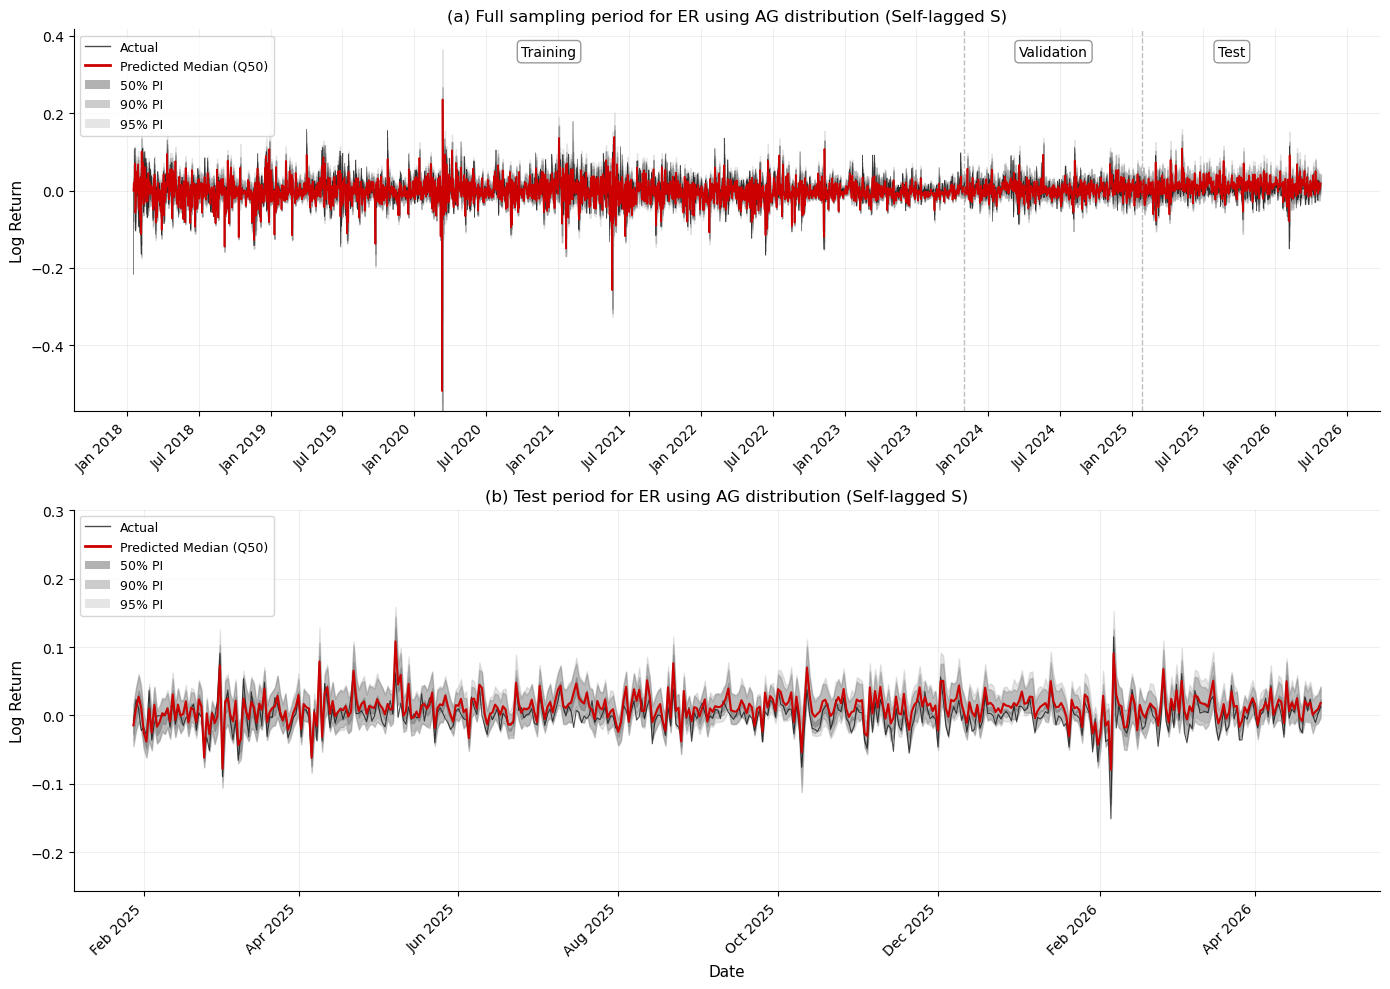

Full period plot saved to hybrid_ernn_self_s_predictions_full.png
Test period plot saved to hybrid_ernn_self_s_predictions_test.png

CROSSOVER ANALYSIS -- ERNN Self S (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):         227     50.00% <-- TAIL
  (0.050, 0.250):           0      0.00%
  (0.250, 0.500):           0      0.00%
  (0.500, 0.750):         282     62.11%
  (0.750, 0.950):           0      0.00%
  (0.950, 0.975):          83     18.28% <-- TAIL
  ------------------------------------------
  Total violations:         592  (21.73% of all pairs)
  Tail violations:          310  (34.14% of tail pairs)


In [29]:
def train_final_model(tau, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridERNN(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        e_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_ernn_loss(y_test, e_test, sigma_test, tau)

    with torch.no_grad():
        est_gamma1 = torch.sigmoid(model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        est_psi    = torch.sigmoid(model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | "
          f"gamma1={est_gamma1:.4f} | gamma2={est_gamma2:.4f} | "
          f"psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'ernn_self_history_tau_{tau}.csv', index=False)

    return model, train_losses, val_losses, e_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all tau levels
# -------------------------
tau_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results    = {}

for tau in tau_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for tau = {tau} (self-lagged)")
    print(f"{'='*60}")
    config = best_configs2[tau]
    model, train_losses, val_losses, e_test_pred = train_final_model(
        tau, config, y_train, X_train, y_val, X_val, y_test, X_test)
    results[tau] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'e_test':       e_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel(results, train_df, val_df, test_df, tau_levels, feature_cols,
                   title_suffix='ER using AG distribution (Self-lagged S)',
                   save_fname='hybrid_ernn_self_s_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()
        with torch.no_grad():
            e_all, _ = model(y_all, X_all)
            all_preds[tau] = e_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    y_min, y_max   = y_all_np.min(), y_all_np.max()
    y_range        = y_max - y_min
    y_label        = y_max + 0.25 * y_range
    test_dates     = test_df.index
    y_test_np      = test_df['log_return'].values
    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t      = y_max_t - y_min_t

    # ============================================================
    # Combined two-panel figure
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_fname}")
    plt.show()
    plt.close()

    # ============================================================
    # Panel (a) -- full period separately
    # ============================================================
    fig_a, ax_a = plt.subplots(1, 1, figsize=(14, 5))
    ax_a.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax_a.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax_a.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax_a.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax_a.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax_a.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax_a.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.text(train_df.index[len(train_df)//2], y_label, 'Training',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(val_df.index[len(val_df)//2], y_label, 'Validation',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(test_df.index[len(test_df)//2], y_label, 'Test',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_a.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_a.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax_a.set_ylabel('Log Return', fontsize=11)
    ax_a.grid(True, alpha=0.2)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    fname_a = save_fname.replace('.png', '_full.png')
    plt.tight_layout()
    plt.savefig(fname_a, dpi=300, bbox_inches='tight')
    print(f"Full period plot saved to {fname_a}")
    plt.close()

    # ============================================================
    # Panel (b) -- test period separately
    # ============================================================
    fig_b, ax_b = plt.subplots(1, 1, figsize=(14, 5))
    ax_b.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax_b.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax_b.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax_b.fill_between(test_dates,
                          all_preds[0.025][train_size + val_size:],
                          all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax_b.fill_between(test_dates,
                          all_preds[0.05][train_size + val_size:],
                          all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax_b.fill_between(test_dates,
                          all_preds[0.25][train_size + val_size:],
                          all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_b.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_b.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax_b.set_xlabel('Date', fontsize=11)
    ax_b.set_ylabel('Log Return', fontsize=11)
    ax_b.grid(True, alpha=0.2)
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    fname_b = save_fname.replace('.png', '_test.png')
    plt.tight_layout()
    plt.savefig(fname_b, dpi=300, bbox_inches='tight')
    print(f"Test period plot saved to {fname_b}")
    plt.close()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- self-lagged S
# -------------------------
all_preds_ernn, train_size, val_size = plot_two_panel(
    results, train_df, val_df, test_df, tau_levels, feature_cols,
    title_suffix='ER using AG distribution (Self-lagged S)',
    save_fname='hybrid_ernn_self_s_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='ERNN'):
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]
    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


total_viol, tail_viol = compute_crossovers(
    all_preds_ernn, tau_levels, train_size, val_size,
    model_name='ERNN Self S'
)

In [31]:
import numpy as np


def compute_ase(y_true, e_pred, tau):
    """
    Asymmetric Squared Error for expectile evaluation.
    ASE = mean(|tau - 1(y < e_hat)| * (y - e_hat)^2)
    """
    y         = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    e         = e_pred if isinstance(e_pred, np.ndarray) else np.array(e_pred)
    indicator = (y < e).astype(float)
    ase       = np.mean(np.abs(tau - indicator) * (y - e)**2)
    return ase


def compute_test_metrics_ernn(results, tau_levels, y_test, X_test, model_name='ERNN'):
    """
    Compute average NLL and ASE on test set across all tau levels.
    """
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'tau':>6} {'NLL':>10} {'ASE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    ase_list = []

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()

        with torch.no_grad():
            e_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_ernn_loss(y_test, e_test, sigma_test, tau).item()

        e_test_np = e_test.numpy()
        y_test_np = y_test.numpy()

        ase = compute_ase(y_test_np, e_test_np, tau)

        nll_list.append(test_nll)
        ase_list.append(ase)

        print(f"  {tau:>6} {test_nll:>10.4f} {ase:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(ase_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average ASE: {np.mean(ase_list):.6f}")

    return np.mean(nll_list), np.mean(ase_list)


# -------------------------
# Test tensors
# -------------------------
X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

tau_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]

# -------------------------
# Run metrics -- ERNN S self-lagged
# -------------------------
avg_nll_ernn_s_self, avg_ase_ernn_s_self = compute_test_metrics_ernn(
    results, tau_levels, y_test, X_test,
    model_name='ERNN S Self-lagged'
)


TEST SET METRICS -- ERNN S Self-lagged
     tau        NLL            ASE
  ----------------------------------
   0.025    -2.4594       0.000019
    0.05    -2.5340       0.000029
    0.25    -2.6599       0.000092
     0.5    -2.6001       0.000149
    0.75    -2.6863       0.000077
    0.95    -2.3382       0.000068
   0.975    -2.2919       0.000044
  ----------------------------------
    Mean    -2.5100       0.000068

  --> Average NLL: -2.5100
  --> Average ASE: 0.000068


In [15]:
# -------------------------
# Output full ranking results
# -------------------------
import glob

def output_full_ranking(tau_levels, prefix='ernn_ranking'):
    """
    Load and display full ranking results for all tau levels.
    prefix: file prefix used when saving -- e.g. 'ernn_ranking' or 'ernn_self_ranking'
    """
    print("\n" + "="*80)
    print(f"FULL RANKING RESULTS -- {prefix.upper()}")
    print("="*80)

    all_ranking_dfs = []

    for tau in tau_levels:
        fname = f'{prefix}_tau_{tau}.csv'
        try:
            df_rank = pd.read_csv(fname)
            all_ranking_dfs.append(df_rank)

            print(f"\n{'='*80}")
            print(f"TAU = {tau} -- Full Ranking ({len(df_rank)} trials)")
            print(f"{'='*80}")
            print(df_rank[['trial', 'nll', 'crp', 'crp_penalty',
                            'rank_nll', 'rank_crp', 'sum_rank',
                            'gamma1', 'gamma2', 'psi', 'sigma']].to_string(index=False))

            best = df_rank.iloc[0]
            print(f"\n  --> Best trial: #{int(best['trial'])} | "
                  f"NLL={best['nll']:.4f} | "
                  f"CRP={best['crp']:.4f} | "
                  f"sum_rank={int(best['sum_rank'])}")

        except FileNotFoundError:
            print(f"  WARNING: {fname} not found -- tau={tau} may not have finished")

    # save combined ranking across all levels
    if all_ranking_dfs:
        combined_df = pd.concat(all_ranking_dfs, ignore_index=True)
        combined_fname = f'{prefix}_all_tau.csv'
        combined_df.to_csv(combined_fname, index=False)
        print(f"\nCombined ranking saved to {combined_fname}")

    # summary table -- best trial per tau level
    print("\n" + "="*80)
    print(f"SUMMARY -- BEST TRIAL PER TAU LEVEL ({prefix.upper()})")
    print("="*80)
    print(f"  {'tau':>6} {'trial':>6} {'nll':>8} {'crp':>8} {'crp_pen':>9} "
          f"{'sum_rank':>9} {'gamma1':>8} {'psi':>8} {'sigma':>8}")

    for tau in tau_levels:
        fname = f'{prefix}_tau_{tau}.csv'
        try:
            df_rank = pd.read_csv(fname)
            best = df_rank.iloc[0]
            print(f"  {tau:>6} {int(best['trial']):>6} {best['nll']:>8.4f} "
                  f"{best['crp']:>8.4f} {best['crp_penalty']:>9.4f} "
                  f"{int(best['sum_rank']):>9} {best['gamma1']:>8.4f} "
                  f"{best['psi']:>8.4f} {best['sigma']:>8.4f}")
        except FileNotFoundError:
            print(f"  {tau:>6} -- file not found")


# -------------------------
# Run for cross-lagged
# -------------------------
tau_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
output_full_ranking(tau_levels, prefix='ernn_ranking')

# -------------------------
# Run for self-lagged
# -------------------------
output_full_ranking(tau_levels, prefix='ernn_self_ranking')


FULL RANKING RESULTS -- ERNN_RANKING

TAU = 0.025 -- Full Ranking (200 trials)
 trial       nll       crp  crp_penalty  rank_nll  rank_crp  sum_rank   gamma1   gamma2      psi    sigma
    88 -2.349737  2.560706     2.435805         8        70        78 0.031391 0.103358 0.941322 0.011465
   182 -2.351088  2.737307     3.018235         7        80        87 0.037810 0.112447 0.918418 0.011553
   171 -2.315728  2.119205     1.252620        35        53        88 0.035094 0.123595 0.952874 0.011629
   122 -2.307040  1.942605     0.888504        43        46        89 0.049076 0.127965 0.941728 0.011857
    51 -2.298332  1.942605     0.888504        49        45        94 0.043708 0.132646 0.905846 0.012387
   191 -2.347493  2.825607     3.332841        10        84        94 0.052624 0.117785 0.935027 0.011650
   142 -2.327235  2.560706     2.435805        24        72        96 0.032474 0.109478 0.930493 0.011743
   181 -2.351399  3.002208     4.008835         6        92        98 0.

# Quantile cross over dealing

In [34]:
# ============================================================
# JOINT HYBRID ERNN — SYMMETRIC SELF-LAGGED
# Monotonic reconstruction imposed on shared FNN output
# ============================================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna

from optuna.samplers import TPESampler


tau_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]


# ------------------------------------------------------------
# Joint Hybrid ERNN
# ------------------------------------------------------------

class JointHybridERNNSelfS(nn.Module):

    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(tau_levels)

        # Level-specific CARE and hybrid parameters
        self.gamma1_raw = nn.Parameter(
            torch.full((self.n_levels,), 1.386)
        )

        self.gamma2_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.zeros(self.n_levels)
        )

        self.sigma_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.5)
        )

        # Shared FNN
        layers = []
        prev_dim = input_dim

        for i in range(config['n_hidden_layers']):

            hidden_dim = config[f'hidden_dim_{i}']

            layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(config['dropout'])
                )

            prev_dim = hidden_dim

        # Output:
        # [median, raw_delta_1, ..., raw_delta_6]
        layers.append(
            nn.Linear(prev_dim, 7)
        )

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():

            if isinstance(module, nn.Linear):

                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(
                        module.weight
                    )

                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(
                        module.weight
                    )

                if module.bias is not None:
                    nn.init.zeros_(module.bias)


    def _get_activation(self, name):

        return {
            'relu': nn.ReLU(),
            'elu':  nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())


    def reconstruct_fnn_expectiles(self, raw_output):

        median = raw_output[:, 0]

        # Six positive time-varying spacings
        delta = (
            F.softplus(raw_output[:, 1:])
            + 1e-6
        )

        fnn_expectiles = torch.stack(
            [
                median
                - delta[:, 2]
                - delta[:, 1]
                - delta[:, 0],

                median
                - delta[:, 2]
                - delta[:, 1],

                median
                - delta[:, 2],

                median,

                median
                + delta[:, 3],

                median
                + delta[:, 3]
                + delta[:, 4],

                median
                + delta[:, 3]
                + delta[:, 4]
                + delta[:, 5]
            ],
            dim=1
        )

        return fnn_expectiles


    def forward(self, y, X):

        gamma1 = torch.sigmoid(
            self.gamma1_raw
        )

        gamma2 = F.softplus(
            self.gamma2_raw
        )

        psi = torch.sigmoid(
            self.psi_raw
        )

        sigma = (
            F.softplus(self.sigma_raw)
            + 1e-6
        )

        raw_fnn = self.fnn(X)

        fnn_expectiles = (
            self.reconstruct_fnn_expectiles(
                raw_fnn
            )
        )

        T = len(y)

        initial_value = torch.zeros(
            self.n_levels,
            dtype=y.dtype,
            device=y.device
        )

        e_care_list = [
            initial_value
        ]

        e_hybrid_list = [
            initial_value.clone()
        ]

        for t in range(1, T):

            # Symmetric self-lagged CARE:
            # uses previous pure CARE output
            care_t = (
                gamma1 * e_care_list[t - 1]
                + gamma2 * torch.abs(y[t - 1])
            )

            hybrid_t = (
                psi * care_t
                + (1.0 - psi)
                * fnn_expectiles[t]
            )

            e_care_list.append(care_t)
            e_hybrid_list.append(hybrid_t)

        e_care = torch.stack(
            e_care_list,
            dim=0
        )

        e_hybrid = torch.stack(
            e_hybrid_list,
            dim=0
        )

        return (
            e_hybrid,
            e_care,
            fnn_expectiles,
            sigma
        )


# ------------------------------------------------------------
# Joint AGD loss
# ------------------------------------------------------------

def joint_hybrid_ernn_loss(
    y,
    e_hybrid,
    sigma,
    tau_levels
):

    losses = []

    for k, tau in enumerate(tau_levels):

        level_loss = hybrid_ernn_loss(
            y,
            e_hybrid[:, k],
            sigma[k],
            tau
        )

        losses.append(level_loss)

    # Average over all seven expectile levels
    return torch.stack(losses).mean()


# ------------------------------------------------------------
# Average asymmetric squared error
# ------------------------------------------------------------

def compute_joint_ase(
    y,
    e_hybrid,
    tau_levels
):

    ase_by_level = []

    for k, tau in enumerate(tau_levels):

        residual = (
            y - e_hybrid[:, k]
        )

        weight = torch.where(
            residual >= 0,
            torch.full_like(residual, tau),
            torch.full_like(residual, 1.0 - tau)
        )

        ase = torch.mean(
            weight * residual.pow(2)
        )

        ase_by_level.append(ase)

    ase_by_level = torch.stack(
        ase_by_level
    )

    average_ase = (
        ase_by_level.mean().item()
    )

    return (
        ase_by_level.detach().cpu().numpy(),
        average_ase
    )


# ------------------------------------------------------------
# Train one configuration
# ------------------------------------------------------------

def train_joint_ernn_self_s(config):

    torch.manual_seed(2026)

    model = JointHybridERNNSelfS(
        X_train.shape[1],
        config
    )

    if config['optimizer'] == 'adam':

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    else:

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):

        model.train()
        optimizer.zero_grad()

        e_train, _, _, sigma_train = model(
            y_train,
            X_train
        )

        train_loss = joint_hybrid_ernn_loss(
            y_train,
            e_train,
            sigma_train,
            tau_levels
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None, float('inf')

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():

            e_val, _, _, sigma_val = model(
                y_val,
                X_val
            )

            val_loss = joint_hybrid_ernn_loss(
                y_val,
                e_val,
                sigma_val,
                tau_levels
            )

        scheduler.step(val_loss)

        if val_loss.item() < best_val_loss:

            best_val_loss = val_loss.item()
            patience_counter = 0

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None, float('inf')

    model.load_state_dict(
        best_model_state
    )

    return model, best_val_loss


# ------------------------------------------------------------
# Optuna objective
# ------------------------------------------------------------

def objective_joint_ernn_self_s(trial):

    config = {
        'n_hidden_layers':
            trial.suggest_int(
                'n_hidden_layers', 1, 3
            ),

        'activation':
            trial.suggest_categorical(
                'activation',
                ['relu', 'elu', 'gelu', 'tanh']
            ),

        'dropout':
            trial.suggest_float(
                'dropout', 0.0, 0.5
            ),

        'layernorm':
            trial.suggest_categorical(
                'layernorm', [True, False]
            ),

        'weight_init':
            trial.suggest_categorical(
                'weight_init',
                ['glorot', 'he']
            ),

        'lr':
            trial.suggest_float(
                'lr',
                1e-4,
                5e-2,
                log=True
            ),

        'optimizer':
            trial.suggest_categorical(
                'optimizer',
                ['adam', 'adamw']
            ),

        'weight_decay':
            trial.suggest_float(
                'weight_decay',
                0.0,
                1e-4
            ),

        'gradient_clip':
            trial.suggest_categorical(
                'gradient_clip',
                [0.1, 1.0, 5.0]
            ),

        'patience':
            trial.suggest_categorical(
                'patience',
                [10, 20, 30]
            )
    }

    for i in range(
        config['n_hidden_layers']
    ):

        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    model, best_val_loss = (
        train_joint_ernn_self_s(config)
    )

    if model is None:
        return float('inf')

    model.eval()

    with torch.no_grad():

        e_val, _, _, sigma_val = model(
            y_val,
            X_val
        )

        final_nll = joint_hybrid_ernn_loss(
            y_val,
            e_val,
            sigma_val,
            tau_levels
        ).item()

        ase_levels, average_ase = (
            compute_joint_ase(
                y_val,
                e_val,
                tau_levels
            )
        )

        gamma1 = torch.sigmoid(
            model.gamma1_raw
        ).cpu().numpy()

        gamma2 = F.softplus(
            model.gamma2_raw
        ).cpu().numpy()

        psi = torch.sigmoid(
            model.psi_raw
        ).cpu().numpy()

        sigma = (
            F.softplus(model.sigma_raw)
            + 1e-6
        ).cpu().numpy()

    trial.set_user_attr(
        'nll',
        final_nll
    )

    trial.set_user_attr(
        'ase',
        average_ase
    )

    trial.set_user_attr(
        'ase_levels',
        ase_levels.tolist()
    )

    trial.set_user_attr(
        'gamma1',
        gamma1.tolist()
    )

    trial.set_user_attr(
        'gamma2',
        gamma2.tolist()
    )

    trial.set_user_attr(
        'psi',
        psi.tolist()
    )

    trial.set_user_attr(
        'sigma',
        sigma.tolist()
    )

    print(
        f"Trial {trial.number}: "
        f"NLL={final_nll:.6f} | "
        f"ASE={average_ase:.8f} | "
        f"lr={config['lr']:.6f} | "
        f"layers={config['n_hidden_layers']} | "
        f"activation={config['activation']} | "
        f"dropout={config['dropout']:.3f}"
    )

    return final_nll


# ------------------------------------------------------------
# Rank-based selection using NLL and ASE
# ------------------------------------------------------------

def select_best_joint_ernn_trial(study):

    trials = [
        trial for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and 'nll' in trial.user_attrs
            and 'ase' in trial.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            "No valid trials were completed."
        )

    sorted_nll = sorted(
        trials,
        key=lambda trial:
            trial.user_attrs['nll']
    )

    nll_ranks = {
        trial.number: rank
        for rank, trial
        in enumerate(sorted_nll, start=1)
    }

    sorted_ase = sorted(
        trials,
        key=lambda trial:
            trial.user_attrs['ase']
    )

    ase_ranks = {
        trial.number: rank
        for rank, trial
        in enumerate(sorted_ase, start=1)
    }

    for trial in trials:

        trial._rank_nll = (
            nll_ranks[trial.number]
        )

        trial._rank_ase = (
            ase_ranks[trial.number]
        )

        trial._sum_rank = (
            trial._rank_nll
            + trial._rank_ase
        )

    best_trial = min(
        trials,
        key=lambda trial: (
            trial._sum_rank,
            trial.user_attrs['nll'],
            trial.user_attrs['ase'],
            trial.number
        )
    )

    return best_trial, trials


# ------------------------------------------------------------
# Run 800 joint trials
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("JOINT ERNN S SELF-LAGGED — 800 TRIALS")
print("=" * 65)

sampler = TPESampler(seed=2026)

study_joint_ernn_self_s = (
    optuna.create_study(
        direction='minimize',
        sampler=sampler
    )
)

study_joint_ernn_self_s.optimize(
    objective_joint_ernn_self_s,
    n_trials=800,
    show_progress_bar=True
)


# ------------------------------------------------------------
# Select best trial
# ------------------------------------------------------------

best_trial, all_trials = (
    select_best_joint_ernn_trial(
        study_joint_ernn_self_s
    )
)

sorted_trials = sorted(
    all_trials,
    key=lambda trial: (
        trial._sum_rank,
        trial.user_attrs['nll'],
        trial.user_attrs['ase']
    )
)

print("\nTop 10 trials by combined rank:")

print(
    f"{'Trial':>7}"
    f"{'NLL':>12}"
    f"{'NLL rank':>12}"
    f"{'ASE':>14}"
    f"{'ASE rank':>12}"
    f"{'Sum':>8}"
)

for trial in sorted_trials[:10]:

    print(
        f"{trial.number:>7}"
        f"{trial.user_attrs['nll']:>12.6f}"
        f"{trial._rank_nll:>12}"
        f"{trial.user_attrs['ase']:>14.8f}"
        f"{trial._rank_ase:>12}"
        f"{trial._sum_rank:>8}"
    )


# ------------------------------------------------------------
# Save full ranking
# ------------------------------------------------------------

ranking_records = []

for trial in all_trials:

    record = {
        'trial': trial.number,
        'nll': trial.user_attrs['nll'],
        'ase': trial.user_attrs['ase'],
        'rank_nll': trial._rank_nll,
        'rank_ase': trial._rank_ase,
        'sum_rank': trial._sum_rank
    }

    record.update(trial.params)
    ranking_records.append(record)

ranking_df = pd.DataFrame(
    ranking_records
)

ranking_df = ranking_df.sort_values(
    ['sum_rank', 'nll', 'ase']
)

ranking_df.to_csv(
    'ernn_self_s_joint_ranking.csv',
    index=False
)


# ------------------------------------------------------------
# Refit selected architecture
# ------------------------------------------------------------

best_config_ernn_self_s = (
    best_trial.params.copy()
)

best_model_ernn_self_s, final_val_loss = (
    train_joint_ernn_self_s(
        best_config_ernn_self_s
    )
)

best_model_ernn_self_s.eval()

with torch.no_grad():

    e_val_final, _, fnn_val_final, sigma_final = (
        best_model_ernn_self_s(
            y_val,
            X_val
        )
    )

    final_nll = joint_hybrid_ernn_loss(
        y_val,
        e_val_final,
        sigma_final,
        tau_levels
    ).item()

    final_ase_levels, final_ase = (
        compute_joint_ase(
            y_val,
            e_val_final,
            tau_levels
        )
    )


# ------------------------------------------------------------
# Save architecture and fitted model
# ------------------------------------------------------------

checkpoint = {
    'model_name':
        'Joint Hybrid ERNN S Self-lagged',

    'tau_levels':
        tau_levels,

    'config':
        best_config_ernn_self_s,

    'best_trial_number':
        best_trial.number,

    'best_trial_nll':
        best_trial.user_attrs['nll'],

    'best_trial_ase':
        best_trial.user_attrs['ase'],

    'refit_validation_nll':
        final_nll,

    'refit_validation_ase':
        final_ase,

    'model_state_dict':
        best_model_ernn_self_s.state_dict()
}

torch.save(
    checkpoint,
    'hybrid_ernn_self_s_joint_best.pt'
)


# ------------------------------------------------------------
# Print estimated parameters
# ------------------------------------------------------------

with torch.no_grad():

    estimated_gamma1 = torch.sigmoid(
        best_model_ernn_self_s.gamma1_raw
    ).cpu().numpy()

    estimated_gamma2 = F.softplus(
        best_model_ernn_self_s.gamma2_raw
    ).cpu().numpy()

    estimated_psi = torch.sigmoid(
        best_model_ernn_self_s.psi_raw
    ).cpu().numpy()

    estimated_sigma = (
        F.softplus(
            best_model_ernn_self_s.sigma_raw
        )
        + 1e-6
    ).cpu().numpy()


print("\n" + "=" * 65)
print("TUNING COMPLETE — JOINT ERNN S SELF-LAGGED")
print("=" * 65)

print(f"Best trial: #{best_trial.number}")
print(f"Validation NLL: {final_nll:.6f}")
print(f"Validation ASE: {final_ase:.8f}")
print(
    f"Best architecture: "
    f"{best_config_ernn_self_s}"
)

print("\nEstimated level-specific parameters:")

for k, tau in enumerate(tau_levels):

    print(
        f"tau={tau:.3f} | "
        f"gamma1={estimated_gamma1[k]:.4f} | "
        f"gamma2={estimated_gamma2[k]:.4f} | "
        f"psi={estimated_psi[k]:.4f} | "
        f"sigma={estimated_sigma[k]:.4f}"
    )

print("\nSaved files:")
print("  ernn_self_s_joint_ranking.csv")
print("  hybrid_ernn_self_s_joint_best.pt")

[I 2026-07-31 15:02:38,122] A new study created in memory with name: no-name-a5e5fc80-cb4b-47bb-a822-b6d7cc353572



JOINT ERNN S SELF-LAGGED — 800 TRIALS


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=1.301410 | ASE=0.00231137 | lr=0.000655 | layers=1 | activation=elu | dropout=0.494
[I 2026-07-31 15:02:54,126] Trial 0 finished with value: 1.3014100790023804 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3014100790023804.
Trial 1: NLL=0.266028 | ASE=0.00012787 | lr=0.006969 | layers=1 | activation=tanh | dropout=0.075
[I 2026-07-31 15:03:10,147] Trial 1 finished with value: 0.2660283148288727 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.266028314828

Loaded best trial: 470
Best architecture: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.11898811212775252, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.0376075749528233, 'optimizer': 'adam', 'weight_decay': 2.3498361700247635e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 105}


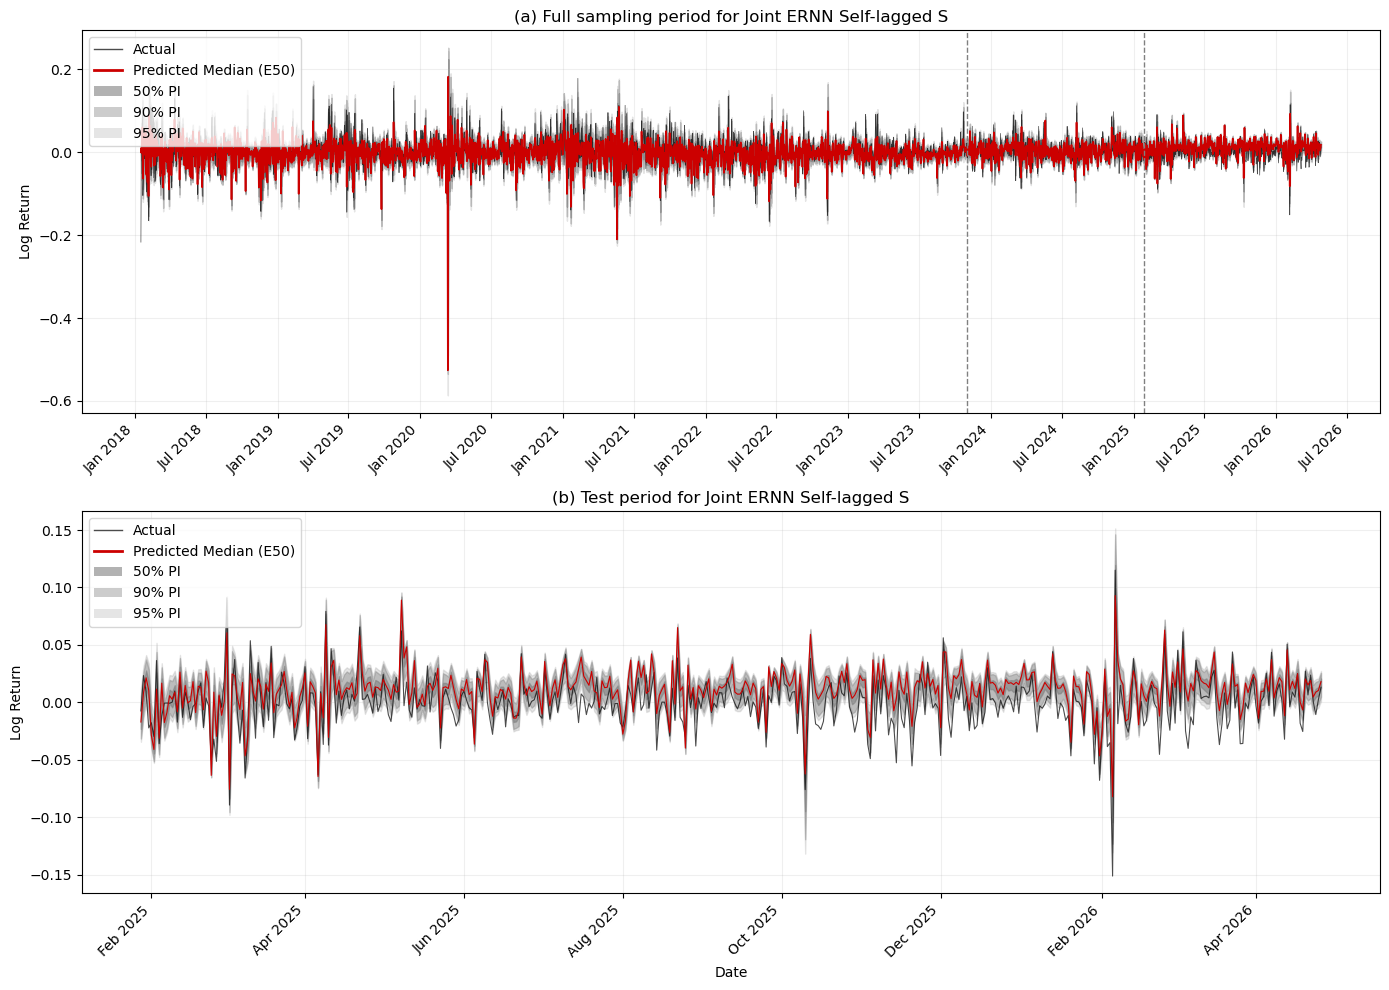

Plot saved to hybrid_ernn_self_s_joint_predictions.png

TEST METRICS — JOINT ERNN S SELF-LAGGED
       tau           NLL           ASE
0.02500000   -2.35848522    0.00003109
0.05000000   -2.42522526    0.00005305
0.25000000   -2.54666305    0.00013212
0.50000000   -2.57810330    0.00015223
0.75000000   -2.64536476    0.00010332
0.95000000   -2.59832788    0.00003505
0.97500000   -2.54906583    0.00002154

Average NLL: -2.528748
Average ASE: 0.00007549

CROSSOVER ANALYSIS — FINAL HYBRID OUTPUT
(0.025, 0.050): 1 (0.22%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 3 (0.66%)
(0.500, 0.750): 10 (2.20%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 11 (2.42%) <-- TAIL

Total violations: 25 (0.92%)
Tail violations: 12 (1.32%)

CROSSOVER ANALYSIS — MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.

In [36]:
# ============================================================
# PLOTTING — JOINT HYBRID ERNN S SELF-LAGGED
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Load best model
# ------------------------------------------------------------

checkpoint = torch.load(
    'hybrid_ernn_self_s_joint_best.pt',
    map_location='cpu',
    weights_only=False
)

tau_levels = checkpoint['tau_levels']
best_config_ernn_self_s = checkpoint['config']

best_model_ernn_self_s = JointHybridERNNSelfS(
    X_train.shape[1],
    best_config_ernn_self_s
)

best_model_ernn_self_s.load_state_dict(
    checkpoint['model_state_dict']
)

best_model_ernn_self_s.eval()

print("Loaded best trial:", checkpoint['best_trial_number'])
print("Best architecture:", best_config_ernn_self_s)


# ------------------------------------------------------------
# Full-sample prediction
# ------------------------------------------------------------

X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)

train_size = len(train_df)
val_size = len(val_df)
test_start = train_size + val_size

with torch.no_grad():

    e_all, care_all, fnn_all, sigma = (
        best_model_ernn_self_s(
            y_all,
            X_all
        )
    )

e_all_np = e_all.cpu().numpy()
fnn_all_np = fnn_all.cpu().numpy()
sigma_np = sigma.cpu().numpy()

e_test_np = e_all_np[test_start:]
fnn_test_np = fnn_all_np[test_start:]
y_test_np = y_all.cpu().numpy()[test_start:]

all_preds = {
    tau: e_all_np[:, k]
    for k, tau in enumerate(tau_levels)
}

all_fnn_preds = {
    tau: fnn_all_np[:, k]
    for k, tau in enumerate(tau_levels)
}


# ============================================================
# Two-panel prediction plot
# ============================================================

actual_color = '#000000'
pred_color = '#CC0000'
pi_color = '#808080'

all_dates = df.index
test_dates = test_df.index
y_all_np = y_all.cpu().numpy()

legend_elements = [
    Line2D(
        [0], [0],
        color=actual_color,
        lw=1,
        alpha=0.7,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=pred_color,
        lw=2,
        label='Predicted Median (E50)'
    ),
    Patch(
        facecolor=pi_color,
        alpha=0.6,
        label='50% PI'
    ),
    Patch(
        facecolor=pi_color,
        alpha=0.4,
        label='90% PI'
    ),
    Patch(
        facecolor=pi_color,
        alpha=0.2,
        label='95% PI'
    )
]

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 10)
)


# ------------------------------------------------------------
# Panel (a): full sample
# ------------------------------------------------------------

ax = axes[0]

ax.plot(
    all_dates,
    y_all_np,
    color=actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    all_dates,
    all_preds[0.500],
    color=pred_color,
    linewidth=1.2
)

ax.fill_between(
    all_dates,
    all_preds[0.025],
    all_preds[0.975],
    color=pi_color,
    alpha=0.2
)

ax.fill_between(
    all_dates,
    all_preds[0.050],
    all_preds[0.950],
    color=pi_color,
    alpha=0.4
)

ax.fill_between(
    all_dates,
    all_preds[0.250],
    all_preds[0.750],
    color=pi_color,
    alpha=0.6
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--',
    linewidth=1
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--',
    linewidth=1
)

ax.set_title(
    '(a) Full sampling period for Joint ERNN Self-lagged S',
    fontsize=12
)

ax.set_ylabel('Log Return')
ax.legend(handles=legend_elements, loc='upper left')
ax.grid(True, alpha=0.2)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha='right'
)


# ------------------------------------------------------------
# Panel (b): test sample
# ------------------------------------------------------------

ax2 = axes[1]

ax2.plot(
    test_dates,
    y_test_np,
    color=actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    test_dates,
    e_test_np[:, 3],
    color=pred_color,
    linewidth=0.8
)

ax2.fill_between(
    test_dates,
    e_test_np[:, 0],
    e_test_np[:, 6],
    color=pi_color,
    alpha=0.2
)

ax2.fill_between(
    test_dates,
    e_test_np[:, 1],
    e_test_np[:, 5],
    color=pi_color,
    alpha=0.4
)

ax2.fill_between(
    test_dates,
    e_test_np[:, 2],
    e_test_np[:, 4],
    color=pi_color,
    alpha=0.6
)

ax2.set_title(
    '(b) Test period for Joint ERNN Self-lagged S',
    fontsize=12
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.legend(handles=legend_elements, loc='upper left')
ax2.grid(True, alpha=0.2)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

plt.setp(
    ax2.xaxis.get_majorticklabels(),
    rotation=45,
    ha='right'
)

plt.tight_layout()

plot_filename = (
    'hybrid_ernn_self_s_joint_predictions.png'
)

plt.savefig(
    plot_filename,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(f"Plot saved to {plot_filename}")


# ============================================================
# Test NLL and ASE
# ============================================================

def compute_ernn_test_metrics(
    y_test,
    e_test,
    sigma,
    tau_levels
):

    y_tensor = torch.tensor(
        y_test,
        dtype=torch.float32
    )

    nll_values = []
    ase_values = []

    print("\n" + "=" * 65)
    print("TEST METRICS — JOINT ERNN S SELF-LAGGED")
    print("=" * 65)

    print(
        f"{'tau':>10}"
        f"{'NLL':>14}"
        f"{'ASE':>14}"
    )

    for k, tau in enumerate(tau_levels):

        e_tensor = torch.tensor(
            e_test[:, k],
            dtype=torch.float32
        )

        sigma_k = torch.tensor(
            sigma[k],
            dtype=torch.float32
        )

        # Same AGD loss used during training
        nll = hybrid_ernn_loss(
            y_tensor,
            e_tensor,
            sigma_k,
            tau
        ).item()

        residual = (
            y_tensor - e_tensor
        )

        weight = torch.where(
            residual >= 0,
            torch.full_like(residual, tau),
            torch.full_like(
                residual,
                1.0 - tau
            )
        )

        ase = torch.mean(
            weight * residual.pow(2)
        ).item()

        nll_values.append(nll)
        ase_values.append(ase)

        print(
            f"{tau:>10.8f}"
            f"{nll:>14.8f}"
            f"{ase:>14.8f}"
        )

    average_nll = np.mean(nll_values)
    average_ase = np.mean(ase_values)

    print(f"\nAverage NLL: {average_nll:.6f}")
    print(f"Average ASE: {average_ase:.8f}")

    return {
        'nll_by_level': nll_values,
        'ase_by_level': ase_values,
        'average_nll': average_nll,
        'average_ase': average_ase
    }


test_metrics_ernn_self_s = (
    compute_ernn_test_metrics(
        y_test_np,
        e_test_np,
        sigma_np,
        tau_levels
    )
)


# ============================================================
# Crossover analysis
# ============================================================

def crossover_analysis_ernn(
    predictions,
    levels,
    output_name
):

    T = predictions.shape[0]

    tail_pairs = [
        (0.025, 0.050),
        (0.950, 0.975)
    ]

    total_violations = 0
    tail_violations = 0

    print("\n" + "=" * 65)
    print(f"CROSSOVER ANALYSIS — {output_name}")
    print("=" * 65)

    for k in range(len(levels) - 1):

        lower_level = levels[k]
        upper_level = levels[k + 1]

        violations = int(
            np.sum(
                predictions[:, k]
                > predictions[:, k + 1]
            )
        )

        percentage = (
            violations / T * 100
        )

        pair = (
            lower_level,
            upper_level
        )

        tail_marker = (
            " <-- TAIL"
            if pair in tail_pairs
            else ""
        )

        print(
            f"({lower_level:.3f}, "
            f"{upper_level:.3f}): "
            f"{violations} "
            f"({percentage:.2f}%)"
            f"{tail_marker}"
        )

        total_violations += violations

        if pair in tail_pairs:
            tail_violations += violations

    total_rate = (
        total_violations
        / (T * 6)
        * 100
    )

    tail_rate = (
        tail_violations
        / (T * 2)
        * 100
    )

    print(
        f"\nTotal violations: "
        f"{total_violations} "
        f"({total_rate:.2f}%)"
    )

    print(
        f"Tail violations: "
        f"{tail_violations} "
        f"({tail_rate:.2f}%)"
    )

    return {
        'total_violations': total_violations,
        'total_rate': total_rate,
        'tail_violations': tail_violations,
        'tail_rate': tail_rate
    }


final_crossover_ernn_self_s = (
    crossover_analysis_ernn(
        e_test_np,
        tau_levels,
        'FINAL HYBRID OUTPUT'
    )
)

fnn_crossover_ernn_self_s = (
    crossover_analysis_ernn(
        fnn_test_np,
        tau_levels,
        'MONOTONIC FNN OUTPUT'
    )
)


# ============================================================
# Save test metrics
# ============================================================

metrics_df = pd.DataFrame({
    'tau': tau_levels,
    'NLL': test_metrics_ernn_self_s[
        'nll_by_level'
    ],
    'ASE': test_metrics_ernn_self_s[
        'ase_by_level'
    ]
})

metrics_df.to_csv(
    'hybrid_ernn_self_s_joint_test_metrics.csv',
    index=False
)

print(
    "\nMetrics saved to "
    "hybrid_ernn_self_s_joint_test_metrics.csv"
)

# Cross over dealing 1b


In [13]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 1B -- JOINT ERNN S Self-LAGGED
# Complete-output non-crossing through positive adjacent spacing
# ============================================================

M1B_DISTRIBUTION = 'ernn'   # 'qrnn' or 'ernn'
M1B_FORM = 's'           # 's' or 'si'
M1B_LAG = 'self'             # 'self' or 'cross'
M1B_N_TRIALS = 800
M1B_MAX_EPOCHS = 800
M1B_BASE_SEED = 2026

m1b_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
m1b_spacing_names = [
    'delta12', 'delta23', 'delta34',
    'delta45', 'delta56', 'delta67',
]
m1b_model_tag = (
    f'method1b_joint_{M1B_DISTRIBUTION}_{M1B_FORM}_{M1B_LAG}'
)


def m1b_validate_inputs():
    required = ('y_train', 'X_train', 'y_val', 'X_val')
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            'Run the notebook data preparation first. Missing: '
            + ', '.join(missing)
        )

    for y_name, x_name in (
        ('y_train', 'X_train'),
        ('y_val', 'X_val'),
    ):
        y_value = globals()[y_name]
        x_value = globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(
            x_value, torch.Tensor
        ):
            raise TypeError(f'{y_name} and {x_name} must be tensors.')
        if y_value.ndim != 1 or x_value.ndim != 2:
            raise ValueError(f'{y_name} must be (T,) and {x_name} (T,p).')
        if len(y_value) != len(x_value):
            raise ValueError(f'{y_name} and {x_name} lengths differ.')


class Method1BJointHybrid(nn.Module):
    """Central hybrid forecast plus six jointly learned positive gaps."""

    def __init__(self, input_dim, config):
        super().__init__()
        self.eps = 1e-6

        # Identifiable statistical/mixing parameters for the median only.
        self.persistence_raw = nn.Parameter(torch.tensor(1.386))
        self.news1_raw = nn.Parameter(torch.tensor(0.3))
        if M1B_FORM == 'si':
            self.news2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))

        # One loss scale per final level.
        self.sigma_raw = nn.Parameter(torch.full((7,), 0.5))

        layers = []
        previous_dim = input_dim
        for index in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{index}']
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            previous_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.median_head = nn.Linear(previous_dim, 1)
        self.spacing_heads = nn.ModuleDict({
            name: nn.Linear(previous_dim + 1, 1)
            for name in m1b_spacing_names
        })

        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    @staticmethod
    def _activation(name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }[name]

    def _positive_spacing(self, features, reference, name):
        spacing_input = torch.cat(
            [features, reference.unsqueeze(1)], dim=1
        )
        raw_spacing = self.spacing_heads[name](spacing_input).squeeze(1)
        return F.softplus(raw_spacing) + self.eps

    def _median_recursion(
        self,
        y,
        median_fnn,
        initial_state=None,
        initial_y=None,
    ):
        if (initial_state is None) != (initial_y is None):
            raise ValueError(
                'initial_state and initial_y must be supplied together.'
            )

        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        news2 = (
            F.softplus(self.news2_raw)
            if M1B_FORM == 'si'
            else None
        )
        psi = torch.sigmoid(self.psi_raw)

        has_state = initial_state is not None
        previous_state = (
            initial_state if has_state else y.new_zeros(())
        )

        statistical_values = []
        hybrid_values = []

        for time_index in range(len(y)):
            if time_index == 0 and not has_state:
                zero = y.new_zeros(())
                statistical_values.append(zero)
                hybrid_values.append(zero)
                continue

            previous_y = (
                initial_y if time_index == 0 else y[time_index - 1]
            )
            absolute_return = torch.abs(previous_y)

            statistical = (
                persistence * previous_state
                + news1 * absolute_return
            )
            if M1B_FORM == 'si':
                statistical = (
                    statistical
                    + news2 * previous_state * absolute_return
                )

            hybrid = psi * statistical + (1 - psi) * median_fnn[
                time_index
            ]
            statistical_values.append(statistical)
            hybrid_values.append(hybrid)

            previous_state = (
                statistical if M1B_LAG == 'self' else hybrid
            )

        return (
            torch.stack(hybrid_values),
            torch.stack(statistical_values),
        )

    def forward(
        self,
        y,
        X,
        initial_state=None,
        initial_y=None,
    ):
        features = self.feature_extractor(X)
        median_fnn = self.median_head(features).squeeze(1)
        median, statistical = self._median_recursion(
            y,
            median_fnn,
            initial_state=initial_state,
            initial_y=initial_y,
        )

        # Outward reconstruction; references remain attached so that
        # all seven losses jointly train the median and inner spacings.
        delta34 = self._positive_spacing(features, median, 'delta34')
        level3 = median - delta34
        delta23 = self._positive_spacing(features, level3, 'delta23')
        level2 = level3 - delta23
        delta12 = self._positive_spacing(features, level2, 'delta12')
        level1 = level2 - delta12

        delta45 = self._positive_spacing(features, median, 'delta45')
        level5 = median + delta45
        delta56 = self._positive_spacing(features, level5, 'delta56')
        level6 = level5 + delta56
        delta67 = self._positive_spacing(features, level6, 'delta67')
        level7 = level6 + delta67

        forecasts = torch.stack(
            [level1, level2, level3, median, level5, level6, level7],
            dim=1,
        )
        spacings = torch.stack(
            [delta12, delta23, delta34, delta45, delta56, delta67],
            dim=1,
        )
        sigma = F.softplus(self.sigma_raw) + self.eps
        continuation_state = (
            statistical if M1B_LAG == 'self' else median
        )
        return forecasts, sigma, continuation_state, statistical, median, spacings


def m1b_joint_nll(y, forecasts, sigma):
    levels = forecasts.new_tensor(m1b_levels)
    residual = y.unsqueeze(1) - forecasts

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(forecasts.dtype)
        check_loss = residual * (levels.unsqueeze(0) - indicator)
        nll = (
            -torch.log(levels * (1 - levels)).unsqueeze(0)
            + torch.log(sigma).unsqueeze(0)
            + check_loss / sigma.unsqueeze(0)
        )
    else:
        weight = torch.abs(
            levels.unsqueeze(0)
            - (residual < 0).to(forecasts.dtype)
        )
        constant = (
            torch.log(
                torch.sqrt(torch.pi / levels)
                + torch.sqrt(torch.pi / (1 - levels))
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma).unsqueeze(0)
            + constant.unsqueeze(0)
            + weight * residual.square() / sigma.square().unsqueeze(0)
        )

    return nll.mean()


def m1b_secondary_metric(y, forecasts):
    levels = forecasts.new_tensor(m1b_levels)
    if M1B_DISTRIBUTION == 'qrnn':
        hit_rate = (y.unsqueeze(1) <= forecasts).float().mean(dim=0)
        by_level = torch.abs(hit_rate - levels)
        return by_level, by_level.mean(), hit_rate

    residual = y.unsqueeze(1) - forecasts
    weight = torch.abs(
        levels.unsqueeze(0)
        - (residual < 0).to(forecasts.dtype)
    )
    by_level = (weight * residual.square()).mean(dim=0)
    return by_level, by_level.mean(), None


def m1b_crossover(forecasts):
    violations = forecasts[:, :-1] > forecasts[:, 1:]
    pair_counts = violations.sum(dim=0)
    sample_size = forecasts.shape[0]
    total = int(pair_counts.sum().item())
    tail = int(pair_counts[0].item() + pair_counts[-1].item())
    return {
        'pair_counts': [int(value) for value in pair_counts.tolist()],
        'total_count': total,
        'total_rate': total / (sample_size * 6),
        'tail_count': tail,
        'tail_rate': tail / (sample_size * 2),
    }


def m1b_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        ),
    }
    for index in range(config['n_hidden_layers']):
        config[f'hidden_dim_{index}'] = trial.suggest_int(
            f'hidden_dim_{index}', 32, 256
        )
    return config


def m1b_fit(config, max_epochs=M1B_MAX_EPOCHS, seed=M1B_BASE_SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = Method1BJointHybrid(X_train.shape[1], config)
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    optimizer = optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_loss = float('inf')
    best_state = None
    patience_counter = 0

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        train_forecasts, sigma, _, _, _, _ = model(y_train, X_train)
        train_loss = m1b_joint_nll(
            y_train[1:], train_forecasts[1:], sigma
        )
        if not torch.isfinite(train_loss):
            return None
        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, _, train_state, _, _, _ = model(y_train, X_train)
            validation_forecasts, validation_sigma, _, _, _, _ = model(
                y_val,
                X_val,
                initial_state=train_state[-1],
                initial_y=y_train[-1],
            )
            validation_loss = m1b_joint_nll(
                y_val, validation_forecasts, validation_sigma
            )

        if not torch.isfinite(validation_loss):
            return None
        scheduler.step(validation_loss.item())
        if validation_loss.item() < best_loss:
            best_loss = validation_loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def m1b_evaluate(model):
    model.eval()
    with torch.no_grad():
        _, _, train_state, _, _, _ = model(y_train, X_train)
        forecasts, sigma, _, _, _, spacings = model(
            y_val,
            X_val,
            initial_state=train_state[-1],
            initial_y=y_train[-1],
        )
        mean_nll = m1b_joint_nll(y_val, forecasts, sigma).item()
        by_level, secondary, hit_rate = m1b_secondary_metric(
            y_val, forecasts
        )

        metrics = {
            'mean_nll': mean_nll,
            'secondary': secondary.item(),
            'secondary_by_level': by_level.tolist(),
            'crossover': m1b_crossover(forecasts),
            'spacing_mean': spacings.mean(dim=0).tolist(),
            'spacing_min': spacings.min(dim=0).values.tolist(),
            'spacing_max': spacings.max(dim=0).values.tolist(),
            'spacing_std': spacings.std(
                dim=0, unbiased=False
            ).tolist(),
            'near_zero_count': (
                spacings <= 1e-5
            ).sum(dim=0).tolist(),
            'persistence': torch.sigmoid(
                model.persistence_raw
            ).item(),
            'news1': F.softplus(model.news1_raw).item(),
            'news2': (
                F.softplus(model.news2_raw).item()
                if M1B_FORM == 'si'
                else np.nan
            ),
            'psi': torch.sigmoid(model.psi_raw).item(),
            'sigma': (
                F.softplus(model.sigma_raw) + model.eps
            ).tolist(),
        }
        if hit_rate is not None:
            metrics['hit_rate'] = hit_rate.tolist()
        return metrics


def m1b_objective(trial):
    config = m1b_suggest_config(trial)
    model = m1b_fit(config)
    if model is None:
        return float('inf')
    metrics = m1b_evaluate(model)
    for name, value in metrics.items():
        trial.set_user_attr(name, value)
    metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
    print(
        f"Trial {trial.number}: NLL={metrics['mean_nll']:.6f} | "
        f"{metric_name}={metrics['secondary']:.8f} | "
        f"crossover={metrics['crossover']['total_rate']:.2%}"
    )
    return metrics['mean_nll']


def m1b_select_by_rank(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'mean_nll' in trial.user_attrs
        and 'secondary' in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError('No valid Method 1b trials.')

    nll_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['mean_nll'], trial.number),
    )
    secondary_order = sorted(
        trials,
        key=lambda trial: (trial.user_attrs['secondary'], trial.number),
    )
    rank_nll = {
        trial.number: rank
        for rank, trial in enumerate(nll_order, 1)
    }
    rank_secondary = {
        trial.number: rank
        for rank, trial in enumerate(secondary_order, 1)
    }
    best = min(
        trials,
        key=lambda trial: (
            rank_nll[trial.number] + rank_secondary[trial.number],
            trial.user_attrs['mean_nll'],
            trial.user_attrs['secondary'],
            trial.number,
        ),
    )
    return best, trials, rank_nll, rank_secondary


m1b_validate_inputs()
print('\n' + '=' * 72)
print(
    f'Tuning Method 1b Joint {M1B_DISTRIBUTION.upper()} '
    f'{M1B_FORM.upper()} {M1B_LAG.title()}-lagged'
)
print('=' * 72)

m1b_study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=M1B_BASE_SEED),
)
m1b_study.optimize(
    m1b_objective,
    n_trials=M1B_N_TRIALS,
    show_progress_bar=True,
)

(
    m1b_best_trial,
    m1b_all_trials,
    m1b_rank_nll,
    m1b_rank_secondary,
) = m1b_select_by_rank(m1b_study)

m1b_ranking_records = []
for trial in m1b_all_trials:
    record = {
        'trial': trial.number,
        'mean_nll': trial.user_attrs['mean_nll'],
        ('mean_hre' if M1B_DISTRIBUTION == 'qrnn' else 'mean_ase'):
            trial.user_attrs['secondary'],
        'rank_nll': m1b_rank_nll[trial.number],
        'rank_secondary': m1b_rank_secondary[trial.number],
        'sum_rank': (
            m1b_rank_nll[trial.number]
            + m1b_rank_secondary[trial.number]
        ),
        'crossover_count': trial.user_attrs['crossover']['total_count'],
        'crossover_rate': trial.user_attrs['crossover']['total_rate'],
        'tail_count': trial.user_attrs['crossover']['tail_count'],
        'tail_rate': trial.user_attrs['crossover']['tail_rate'],
        'persistence': trial.user_attrs['persistence'],
        'news1': trial.user_attrs['news1'],
        'news2': trial.user_attrs['news2'],
        'psi': trial.user_attrs['psi'],
    }
    for index, level in enumerate(m1b_levels):
        metric_label = 'hre' if M1B_DISTRIBUTION == 'qrnn' else 'ase'
        record[f'{metric_label}_{level:.3f}'] = trial.user_attrs[
            'secondary_by_level'
        ][index]
        record[f'sigma_{level:.3f}'] = trial.user_attrs['sigma'][index]
    record.update(trial.params)
    m1b_ranking_records.append(record)

m1b_ranking_df = pd.DataFrame(m1b_ranking_records).sort_values(
    ['sum_rank', 'mean_nll', 'trial']
)
m1b_ranking_filename = f'{m1b_model_tag}_ranking.csv'
m1b_ranking_df.to_csv(m1b_ranking_filename, index=False)

m1b_best_config = m1b_best_trial.params.copy()
m1b_best_model = m1b_fit(m1b_best_config)
if m1b_best_model is None:
    raise RuntimeError('Selected Method 1b configuration failed to refit.')
m1b_best_metrics = m1b_evaluate(m1b_best_model)

m1b_checkpoint_filename = f'{m1b_model_tag}_best.pt'
torch.save(
    {
        'model_state_dict': m1b_best_model.state_dict(),
        'config': m1b_best_config,
        'levels': m1b_levels,
        'distribution': M1B_DISTRIBUTION,
        'form': M1B_FORM,
        'lag': M1B_LAG,
        'validation_metrics': m1b_best_metrics,
    },
    m1b_checkpoint_filename,
)

m1b_metric_name = 'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
print('\n' + '=' * 72)
print('METHOD 1B TUNING COMPLETE')
print('=' * 72)
print(f'Best trial: #{m1b_best_trial.number}')
print(f"Mean validation NLL: {m1b_best_metrics['mean_nll']:.6f}")
print(
    f"Mean validation {m1b_metric_name}: "
    f"{m1b_best_metrics['secondary']:.8f}"
)
print(
    f"Final crossover: {m1b_best_metrics['crossover']['total_count']} "
    f"({m1b_best_metrics['crossover']['total_rate']:.2%})"
)
print(f'Saved ranking: {m1b_ranking_filename}')
print(f'Saved model: {m1b_checkpoint_filename}')



[I 2026-08-23 17:43:16,007] A new study created in memory with name: no-name-a5534787-c4c1-42b6-ade3-b46a115c15f1



Tuning Method 1b Joint ERNN S Self-lagged


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=1.000079 | ASE=0.00029834 | crossover=0.00%
[I 2026-08-23 17:45:02,721] Trial 0 finished with value: 1.0000790357589722 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.0000790357589722.
Trial 1: NLL=-2.318064 | ASE=0.00007915 | crossover=0.00%
[I 2026-08-23 17:46:40,473] Trial 1 finished with value: -2.318063735961914 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -2.318063735961914.
Trial 2: NLL=1.326444 | ASE=0.00229822 | crossover=0.00%
[I 2026-08-23 17:

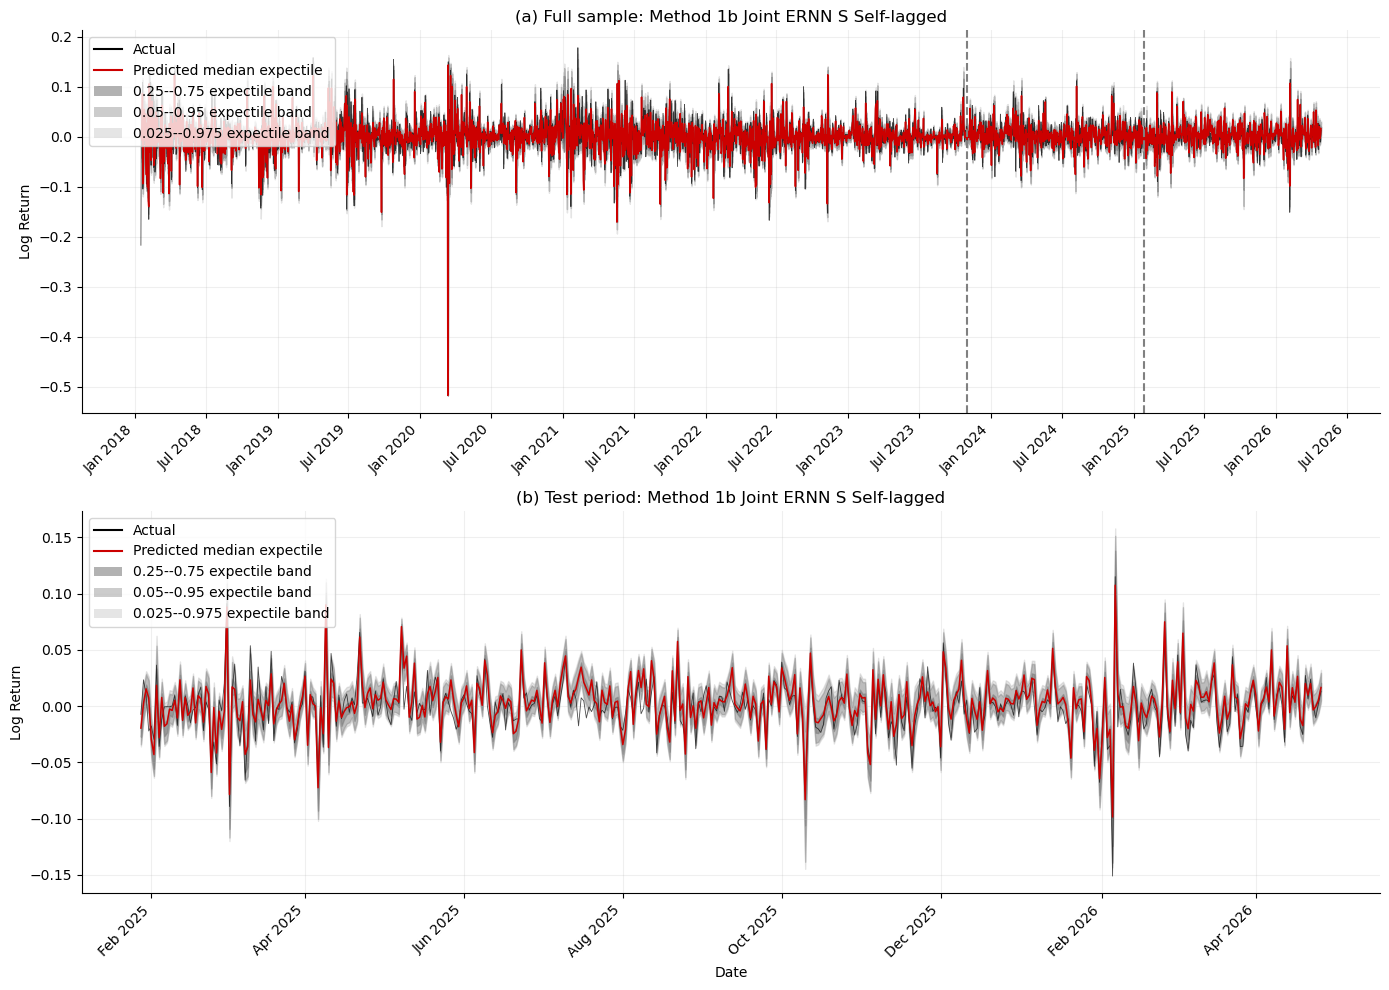

Plot saved to: method1b_joint_ernn_s_self_predictions.png

TEST METRICS -- METHOD 1B JOINT ERNN S SELF-LAGGED
 level       NLL      ASE    sigma
 0.025 -2.672645 0.000018 0.007902
 0.050 -2.750580 0.000028 0.009858
 0.250 -2.873832 0.000066 0.015202
 0.500 -2.924315 0.000071 0.016506
 0.750 -2.930873 0.000057 0.014592
 0.950 -2.812321 0.000025 0.009199
 0.975 -2.750164 0.000016 0.007352

Average NLL: -2.816390
Average ASE: 0.00004008

CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS
 Lower  Upper  Violations  Rate
 0.025  0.050           0   0.0
 0.050  0.250           0   0.0
 0.250  0.500           0   0.0
 0.500  0.750           0   0.0
 0.750  0.950           0   0.0
 0.950  0.975           0   0.0

Total violations: 0
Tail violations: 0

LEARNED SPACING DIAGNOSTICS -- TEST PERIOD
Spacing  Lower_Level  Upper_Level  Mean_Delta  Minimum_Delta  Maximum_Delta  Delta_Std  Near_Zero_Count  Near_Zero_Rate
delta12        0.025        0.050    0.002257       0.001385       0.011294   0.00070

In [15]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 1B -- ERNN S
# Self-LAGGED
# ============================================================

m1b_plot_pairs = list(zip(m1b_levels[:-1], m1b_levels[1:]))
m1b_plot_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

if 'm1b_best_model' not in globals():
    m1b_plot_checkpoint_filename = f'{m1b_model_tag}_best.pt'
    m1b_plot_checkpoint = torch.load(
        m1b_plot_checkpoint_filename,
        map_location='cpu',
        weights_only=False,
    )
    m1b_best_model = Method1BJointHybrid(
        X_train.shape[1], m1b_plot_checkpoint['config']
    )
    m1b_best_model.load_state_dict(
        m1b_plot_checkpoint['model_state_dict']
    )

m1b_best_model.eval()

m1b_plot_X_all = torch.tensor(
    df[feature_cols].values, dtype=torch.float32
)
m1b_plot_y_all = torch.tensor(
    df['log_return'].values, dtype=torch.float32
)

with torch.no_grad():
    (
        m1b_plot_forecasts_all,
        m1b_plot_sigma,
        _,
        _,
        _,
        m1b_plot_spacings_all,
    ) = m1b_best_model(m1b_plot_y_all, m1b_plot_X_all)

m1b_plot_forecasts_np = m1b_plot_forecasts_all.cpu().numpy()
m1b_plot_spacings_np = m1b_plot_spacings_all.cpu().numpy()
m1b_plot_test_start = len(train_df) + len(val_df)
m1b_plot_forecasts_test = m1b_plot_forecasts_all[
    m1b_plot_test_start:
]
m1b_plot_spacings_test = m1b_plot_spacings_all[m1b_plot_test_start:]
m1b_plot_y_test = m1b_plot_y_all[m1b_plot_test_start:]

if len(m1b_plot_forecasts_test) != len(test_df):
    raise ValueError(
        'Test forecast length does not match test_df. Check the split.'
    )


def m1b_draw_panel(axis, dates, actual, forecasts):
    axis.plot(dates, actual, color='#000000', linewidth=0.6, alpha=0.7)
    axis.plot(
        dates, forecasts[:, 3], color='#CC0000', linewidth=1.1
    )
    axis.fill_between(
        dates, forecasts[:, 0], forecasts[:, 6],
        color='#808080', alpha=0.20,
    )
    axis.fill_between(
        dates, forecasts[:, 1], forecasts[:, 5],
        color='#808080', alpha=0.40,
    )
    axis.fill_between(
        dates, forecasts[:, 2], forecasts[:, 4],
        color='#808080', alpha=0.60,
    )
    axis.set_ylabel('Log Return')
    axis.grid(True, alpha=0.2)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


m1b_plot_distribution_label = M1B_DISTRIBUTION.upper()
m1b_plot_form_label = M1B_FORM.upper()
m1b_plot_lag_label = M1B_LAG.title()
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

m1b_draw_panel(
    axes[0], df.index, df['log_return'].values, m1b_plot_forecasts_np
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    f'(a) Full sample: Method 1b Joint {m1b_plot_distribution_label} '
    f'{m1b_plot_form_label} {m1b_plot_lag_label}-lagged'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m1b_draw_panel(
    axes[1],
    test_df.index,
    test_df['log_return'].values,
    m1b_plot_forecasts_np[m1b_plot_test_start:],
)
axes[1].set_title(
    f'(b) Test period: Method 1b Joint '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label}-lagged'
)
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

if M1B_DISTRIBUTION == 'qrnn':
    median_label = 'Predicted Median (Q50)'
    band_labels = ['50% PI', '90% PI', '95% PI']
else:
    median_label = 'Predicted median expectile'
    band_labels = [
        '0.25--0.75 expectile band',
        '0.05--0.95 expectile band',
        '0.025--0.975 expectile band',
    ]

m1b_legend = [
    Line2D([0], [0], color='#000000', label='Actual'),
    Line2D([0], [0], color='#CC0000', label=median_label),
    Patch(facecolor='#808080', alpha=0.60, label=band_labels[0]),
    Patch(facecolor='#808080', alpha=0.40, label=band_labels[1]),
    Patch(facecolor='#808080', alpha=0.20, label=band_labels[2]),
]
for axis in axes:
    axis.legend(handles=m1b_legend, loc='upper left')
    plt.setp(
        axis.xaxis.get_majorticklabels(), rotation=45, ha='right'
    )

plt.tight_layout()
m1b_plot_png = f'{m1b_model_tag}_predictions.png'
plt.savefig(m1b_plot_png, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f'Plot saved to: {m1b_plot_png}')


# ============================================================
# Test metrics by level
# ============================================================

m1b_plot_metric_rows = []
for index, level in enumerate(m1b_levels):
    forecast = m1b_plot_forecasts_test[:, index]
    sigma = m1b_plot_sigma[index]
    residual = m1b_plot_y_test - forecast

    if M1B_DISTRIBUTION == 'qrnn':
        indicator = (residual < 0).to(residual.dtype)
        check_loss = residual * (level - indicator)
        nll = (
            -torch.log(residual.new_tensor(level * (1 - level)))
            + torch.log(sigma)
            + check_loss / sigma
        ).mean().item()
        hit_rate = (
            m1b_plot_y_test <= forecast
        ).float().mean().item()
        secondary = abs(hit_rate - level)
        row = {
            'level': level,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': secondary,
            'sigma': sigma.item(),
        }
    else:
        weight = torch.abs(
            residual.new_tensor(level)
            - (residual < 0).to(residual.dtype)
        )
        weighted_squared_error = weight * residual.square()
        constant = (
            torch.log(
                torch.sqrt(residual.new_tensor(torch.pi / level))
                + torch.sqrt(
                    residual.new_tensor(torch.pi / (1 - level))
                )
            )
            - np.log(2.0)
        )
        nll = (
            torch.log(sigma)
            + constant
            + weighted_squared_error / sigma.square()
        ).mean().item()
        secondary = weighted_squared_error.mean().item()
        row = {
            'level': level,
            'NLL': nll,
            'ASE': secondary,
            'sigma': sigma.item(),
        }

    m1b_plot_metric_rows.append(row)

m1b_plot_metrics_df = pd.DataFrame(m1b_plot_metric_rows)
m1b_plot_metric_column = (
    'HRE' if M1B_DISTRIBUTION == 'qrnn' else 'ASE'
)
print('\n' + '=' * 72)
print(
    f'TEST METRICS -- METHOD 1B JOINT '
    f'{m1b_plot_distribution_label} {m1b_plot_form_label} '
    f'{m1b_plot_lag_label.upper()}-LAGGED'
)
print('=' * 72)
print(m1b_plot_metrics_df.to_string(index=False))
print(f"\nAverage NLL: {m1b_plot_metrics_df['NLL'].mean():.6f}")
print(
    f'Average {m1b_plot_metric_column}: '
    f"{m1b_plot_metrics_df[m1b_plot_metric_column].mean():.8f}"
)


# ============================================================
# Crossover and learned-spacing diagnostics
# ============================================================

m1b_plot_crossover_rows = []
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    count = int((
        m1b_plot_forecasts_test[:, index]
        > m1b_plot_forecasts_test[:, index + 1]
    ).sum().item())
    m1b_plot_crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': count,
        'Rate': count / len(m1b_plot_y_test),
    })

m1b_plot_crossover_df = pd.DataFrame(m1b_plot_crossover_rows)
m1b_plot_total = int(m1b_plot_crossover_df['Violations'].sum())
m1b_plot_tail = int(
    m1b_plot_crossover_df.iloc[0]['Violations']
    + m1b_plot_crossover_df.iloc[-1]['Violations']
)
print('\n' + '=' * 72)
print('CROSSOVER ANALYSIS -- FINAL METHOD 1B FORECASTS')
print('=' * 72)
print(m1b_plot_crossover_df.to_string(index=False))
print(f'\nTotal violations: {m1b_plot_total}')
print(f'Tail violations: {m1b_plot_tail}')

m1b_plot_spacing_rows = []
for index, (name, pair) in enumerate(zip(
    m1b_spacing_names, m1b_plot_pairs
)):
    spacing = m1b_plot_spacings_test[:, index]
    m1b_plot_spacing_rows.append({
        'Spacing': name,
        'Lower_Level': pair[0],
        'Upper_Level': pair[1],
        'Mean_Delta': spacing.mean().item(),
        'Minimum_Delta': spacing.min().item(),
        'Maximum_Delta': spacing.max().item(),
        'Delta_Std': spacing.std(unbiased=False).item(),
        'Near_Zero_Count': int((spacing <= 1e-5).sum().item()),
        'Near_Zero_Rate': (
            spacing <= 1e-5
        ).float().mean().item(),
    })

m1b_plot_spacing_df = pd.DataFrame(m1b_plot_spacing_rows)
print('\n' + '=' * 72)
print('LEARNED SPACING DIAGNOSTICS -- TEST PERIOD')
print('=' * 72)
print(m1b_plot_spacing_df.to_string(index=False))


# ============================================================
# Detailed predictions and saved outputs
# ============================================================

m1b_plot_predictions_df = pd.DataFrame({
    'Date': pd.to_datetime(test_df.index),
    'Actual': test_df['log_return'].values,
})
m1b_plot_prefix = 'Q' if M1B_DISTRIBUTION == 'qrnn' else 'E'
for index, level in enumerate(m1b_levels):
    m1b_plot_predictions_df[f'{m1b_plot_prefix}_{level:.3f}'] = (
        m1b_plot_forecasts_np[m1b_plot_test_start:, index]
    )
for index, (lower, upper) in enumerate(m1b_plot_pairs):
    m1b_plot_predictions_df[
        f'Gap_{lower:.3f}_{upper:.3f}'
    ] = m1b_plot_spacings_np[m1b_plot_test_start:, index]

m1b_plot_metrics_file = f'{m1b_model_tag}_test_metrics.csv'
m1b_plot_crossover_file = f'{m1b_model_tag}_crossover.csv'
m1b_plot_spacing_file = f'{m1b_model_tag}_delta_summary.csv'
m1b_plot_predictions_file = f'{m1b_model_tag}_test_predictions.csv'

m1b_plot_metrics_df.to_csv(m1b_plot_metrics_file, index=False)
m1b_plot_crossover_df.to_csv(m1b_plot_crossover_file, index=False)
m1b_plot_spacing_df.to_csv(m1b_plot_spacing_file, index=False)
m1b_plot_predictions_df.to_csv(m1b_plot_predictions_file, index=False)

print('\nSaved Method 1b outputs:')
for filename in (
    m1b_plot_png,
    m1b_plot_metrics_file,
    m1b_plot_crossover_file,
    m1b_plot_spacing_file,
    m1b_plot_predictions_file,
):
    print(f'  {filename}')



# Cross over dealing 2

In [39]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 2 -- SEQUENTIAL HYBRID ERNN S SELF-LAGGED
# Seven separate models; 200 Optuna trials per level
# Selection: validation NLL rank + validation ASE rank
# ============================================================

m2_ernn_self_s_levels = [
    0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975
]

m2_ernn_self_s_order = [
    0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025
]

m2_ernn_self_s_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}

m2_ernn_self_s_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower',
}

M2_ERNN_SELF_S_DELTA = 1e-6
M2_ERNN_SELF_S_SMOOTH_A = 1e-3
M2_ERNN_SELF_S_PSI_MARGIN = 1e-4
M2_ERNN_SELF_S_N_TRIALS = 200
M2_ERNN_SELF_S_MAX_EPOCHS = 200
M2_ERNN_SELF_S_BASE_SEED = 2026


def m2_ernn_self_s_scaled_softplus(x):
    return M2_ERNN_SELF_S_SMOOTH_A * F.softplus(
        x / M2_ERNN_SELF_S_SMOOTH_A
    )


class M2SequentialERNNSelfS(nn.Module):
    def __init__(self, input_dim, config, direction=None):
        super().__init__()

        self.direction = direction

        self.gamma1_raw = nn.Parameter(torch.tensor(1.386))
        self.gamma2_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        prev_dim = fnn_input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(module.weight)

                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }.get(name, nn.ReLU())

    def constrain_fnn(self, f_raw, care, e_reference, psi):
        denominator = 1.0 - psi

        if self.direction == 'upper':
            boundary = (
                e_reference
                + M2_ERNN_SELF_S_DELTA
                - psi * care
            ) / denominator

            return boundary + m2_ernn_self_s_scaled_softplus(
                f_raw - boundary
            )

        if self.direction == 'lower':
            boundary = (
                e_reference
                - M2_ERNN_SELF_S_DELTA
                - psi * care
            ) / denominator

            return boundary - m2_ernn_self_s_scaled_softplus(
                boundary - f_raw
            )

        return f_raw

    def forward(
        self,
        y,
        X,
        e_reference=None,
        initial_care=None,
        initial_y=None,
    ):
        gamma1 = torch.sigmoid(self.gamma1_raw)
        gamma2 = F.softplus(self.gamma2_raw)
        psi = (
            1.0 - M2_ERNN_SELF_S_PSI_MARGIN
        ) * torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + 1e-6

        if self.direction is None:
            X_fnn = X
        else:
            if e_reference is None:
                raise ValueError(
                    'Reference forecasts are required for non-median models.'
                )

            e_reference = e_reference.detach()
            X_fnn = torch.cat([X, e_reference.unsqueeze(1)], dim=1)

        f_raw = self.fnn(X_fnn).squeeze(-1)

        if (initial_care is None) != (initial_y is None):
            raise ValueError(
                'initial_care and initial_y must be supplied together.'
            )

        has_initial_state = initial_care is not None
        previous_care = (
            initial_care
            if has_initial_state
            else torch.zeros((), dtype=y.dtype, device=y.device)
        )

        e_hybrid_list = []
        e_care_list = []
        f_constrained_list = []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                care_t = torch.zeros((), dtype=y.dtype, device=y.device)

                if self.direction is None:
                    f_constrained_t = f_raw[t]
                    hybrid_t = torch.zeros((), dtype=y.dtype, device=y.device)
                else:
                    f_constrained_t = self.constrain_fnn(
                        f_raw[t], care_t, e_reference[t], psi
                    )
                    hybrid_t = (
                        psi * care_t
                        + (1.0 - psi) * f_constrained_t
                    )
            else:
                previous_y = initial_y if t == 0 else y[t - 1]

                # Symmetric self-lagged CARE:
                # the lag is the previous pure CARE output.
                care_t = (
                    gamma1 * previous_care
                    + gamma2 * torch.abs(previous_y)
                )

                if self.direction is None:
                    f_constrained_t = f_raw[t]
                else:
                    f_constrained_t = self.constrain_fnn(
                        f_raw[t], care_t, e_reference[t], psi
                    )

                hybrid_t = (
                    psi * care_t
                    + (1.0 - psi) * f_constrained_t
                )

            e_care_list.append(care_t)
            f_constrained_list.append(f_constrained_t)
            e_hybrid_list.append(hybrid_t)
            previous_care = care_t

        return (
            torch.stack(e_hybrid_list),
            torch.stack(e_care_list),
            f_raw,
            torch.stack(f_constrained_list),
            sigma,
        )


def m2_ernn_self_s_loss(y, e, sigma, tau):
    return hybrid_ernn_loss(y, e, sigma, tau)

def m2_ernn_self_s_ase(y, e, tau):
    residual = y - e
    weight = torch.where(
        residual >= 0,
        torch.full_like(residual, tau),
        torch.full_like(residual, 1.0 - tau),
    )
    return torch.mean(weight * residual.pow(2)).item()

def m2_ernn_self_s_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical('layernorm', [True, False]),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}', 32, 256
        )

    return config


def m2_ernn_self_s_make_optimizer(model, config):
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    return optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )


def m2_ernn_self_s_train_config(
    config,
    tau,
    direction,
    e_reference_train=None,
    e_reference_val=None,
    seed=2026,
):
    torch.manual_seed(seed)

    model = M2SequentialERNNSelfS(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction,
    )
    optimizer = m2_ernn_self_s_make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(M2_ERNN_SELF_S_MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()

        q_train, _, _, _, sigma = model(
            y_train, X_train, e_reference_train
        )
        train_loss = m2_ernn_self_s_loss(
            y_train[1:], q_train[1:], sigma, tau
        )

        if torch.isnan(train_loss) or torch.isinf(train_loss):
            return None

        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, e_care_train, _, _, _ = model(
                y_train, X_train, e_reference_train
            )
            q_val, _, _, _, sigma_val = model(
                y_val,
                X_val,
                e_reference_val,
                initial_care=e_care_train[-1],
                initial_y=y_train[-1],
            )
            val_loss = m2_ernn_self_s_loss(
                y_val, q_val, sigma_val, tau
            )

        scheduler.step(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def m2_ernn_self_s_predict_train_val(
    model,
    e_reference_train=None,
    e_reference_val=None,
):
    model.eval()
    with torch.no_grad():
        q_train, e_care_train, _, _, _ = model(
            y_train, X_train, e_reference_train
        )
        q_val, _, _, _, sigma = model(
            y_val,
            X_val,
            e_reference_val,
            initial_care=e_care_train[-1],
            initial_y=y_train[-1],
        )

    return q_train.detach(), q_val.detach(), sigma.detach()


def m2_ernn_self_s_evaluate(
    model,
    tau,
    e_reference_train=None,
    e_reference_val=None,
):
    _, q_val, sigma = m2_ernn_self_s_predict_train_val(
        model, e_reference_train, e_reference_val
    )
    nll = m2_ernn_self_s_loss(y_val, q_val, sigma, tau).item()
    ase = m2_ernn_self_s_ase(y_val, q_val, tau)

    return {
        'nll': nll,
        'ase': ase,
        'gamma1': torch.sigmoid(model.gamma1_raw).item(),
        'gamma2': F.softplus(model.gamma2_raw).item(),
        'psi': (
            (1.0 - M2_ERNN_SELF_S_PSI_MARGIN)
            * torch.sigmoid(model.psi_raw)
        ).item(),
        'sigma': (F.softplus(model.sigma_raw) + 1e-6).item(),
    }


def m2_ernn_self_s_select_by_rank(study):
    trials = [
        trial
        for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'nll' in trial.user_attrs
        and 'ase' in trial.user_attrs
    ]

    if not trials:
        raise RuntimeError('No valid completed Optuna trials.')

    for trial in trials:
        trial._nll = trial.user_attrs['nll']
        trial._ase = trial.user_attrs['ase']

    for rank, trial in enumerate(
        sorted(trials, key=lambda item: item._nll), start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(trials, key=lambda item: item._ase), start=1
    ):
        trial._rank_ase = rank

    best = min(
        trials,
        key=lambda trial: (
            trial._rank_nll + trial._rank_ase,
            trial._nll,
            trial._ase,
            trial.number,
        ),
    )
    return best, trials


# ============================================================
# Sequential tuning
# ============================================================

m2_ernn_self_s_final_models = {}
m2_ernn_self_s_best_configs = {}
m2_ernn_self_s_validation_metrics = {}
m2_ernn_self_s_train_predictions = {}
m2_ernn_self_s_val_predictions = {}


for level_index, tau in enumerate(m2_ernn_self_s_order):
    direction = m2_ernn_self_s_direction[tau]
    reference_tau = m2_ernn_self_s_reference[tau]
    level_seed = M2_ERNN_SELF_S_BASE_SEED + level_index

    if reference_tau is None:
        e_reference_train = None
        e_reference_val = None
    else:
        e_reference_train = m2_ernn_self_s_train_predictions[
            reference_tau
        ]
        e_reference_val = m2_ernn_self_s_val_predictions[
            reference_tau
        ]

    def m2_ernn_self_s_objective(trial):
        config = m2_ernn_self_s_suggest_config(trial)
        model = m2_ernn_self_s_train_config(
            config=config,
            tau=tau,
            direction=direction,
            e_reference_train=e_reference_train,
            e_reference_val=e_reference_val,
            seed=level_seed,
        )

        if model is None:
            return float('inf')

        metrics = m2_ernn_self_s_evaluate(
            model,
            tau,
            e_reference_train,
            e_reference_val,
        )

        for name, value in metrics.items():
            trial.set_user_attr(name, value)

        print(
            f"Trial {trial.number}: tau={tau:.3f} | "
            f"NLL={metrics['nll']:.6f} | "
            f"ASE={metrics['ase']:.8f}"
        )
        return metrics['nll']

    print('\n' + '=' * 70)
    print(
        f'Tuning Method 2 ERNN S Self-lagged: tau={tau:.3f} | '
        f'direction={direction}'
    )
    print('=' * 70)

    sampler = TPESampler(seed=level_seed)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(
        m2_ernn_self_s_objective,
        n_trials=M2_ERNN_SELF_S_N_TRIALS,
        show_progress_bar=True,
    )

    best_trial, all_trials = m2_ernn_self_s_select_by_rank(study)
    best_config = best_trial.params.copy()

    ranking_records = []
    for trial in all_trials:
        record = {
            'tau': tau,
            'trial': trial.number,
            'nll': trial._nll,
            'ase': trial._ase,
            'rank_nll': trial._rank_nll,
            'rank_ase': trial._rank_ase,
            'sum_rank': trial._rank_nll + trial._rank_ase,
            'gamma1': trial.user_attrs['gamma1'],
            'gamma2': trial.user_attrs['gamma2'],
            'psi': trial.user_attrs['psi'],
            'sigma': trial.user_attrs['sigma'],
        }
        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records).sort_values(
        ['sum_rank', 'nll', 'ase']
    )
    ranking_file = (
        f'method2_sequential_ernn_s_self_ranking_tau_{tau:.3f}.csv'
    )
    ranking_df.to_csv(ranking_file, index=False)

    final_model = m2_ernn_self_s_train_config(
        config=best_config,
        tau=tau,
        direction=direction,
        e_reference_train=e_reference_train,
        e_reference_val=e_reference_val,
        seed=level_seed,
    )
    final_metrics = m2_ernn_self_s_evaluate(
        final_model,
        tau,
        e_reference_train,
        e_reference_val,
    )
    q_train_final, q_val_final, _ = (
        m2_ernn_self_s_predict_train_val(
            final_model,
            e_reference_train,
            e_reference_val,
        )
    )

    m2_ernn_self_s_final_models[tau] = final_model
    m2_ernn_self_s_best_configs[tau] = best_config
    m2_ernn_self_s_validation_metrics[tau] = final_metrics
    m2_ernn_self_s_train_predictions[tau] = q_train_final
    m2_ernn_self_s_val_predictions[tau] = q_val_final

    print(f'Best trial: #{best_trial.number}')
    print(
        f"NLL rank={best_trial._rank_nll} | "
        f"ASE rank={best_trial._rank_ase} | "
        f"Sum={best_trial._rank_nll + best_trial._rank_ase}"
    )
    print(
        f"Validation NLL={final_metrics['nll']:.6f} | "
        f"ASE={final_metrics['ase']:.8f}"
    )
    print(f'Ranking saved to: {ranking_file}')


# Save every fitted level and all information needed for plotting.
torch.save(
    {
        'model_state_dicts': {
            tau: model.state_dict()
            for tau, model in m2_ernn_self_s_final_models.items()
        },
        'configs': m2_ernn_self_s_best_configs,
        'directions': m2_ernn_self_s_direction,
        'reference_levels': m2_ernn_self_s_reference,
        'estimation_order': m2_ernn_self_s_order,
        'tau_levels': m2_ernn_self_s_levels,
        'validation_metrics': m2_ernn_self_s_validation_metrics,
        'delta': M2_ERNN_SELF_S_DELTA,
        'smooth_a': M2_ERNN_SELF_S_SMOOTH_A,
    },
    'method2_sequential_ernn_s_self_best.pt',
)


print('\n' + '=' * 70)
print('TUNING COMPLETE -- METHOD 2 ERNN S SELF-LAGGED')
print('=' * 70)

for tau in m2_ernn_self_s_levels:
    metrics = m2_ernn_self_s_validation_metrics[tau]
    print(
        f"tau={tau:.3f} | NLL={metrics['nll']:.6f} | "
        f"ASE={metrics['ase']:.8f}"
    )

print('\nSaved: method2_sequential_ernn_s_self_best.pt')

[I 2026-08-09 16:00:07,233] A new study created in memory with name: no-name-333ce4a3-b35b-44c7-b5bb-fc343dde7421



Tuning Method 2 ERNN S Self-lagged: tau=0.500 | direction=None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.500 | NLL=0.802543 | ASE=0.00141911
[I 2026-08-09 16:00:33,809] Trial 0 finished with value: 0.8025426864624023 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8025426864624023.
Trial 1: tau=0.500 | NLL=-0.227482 | ASE=0.00023108
[I 2026-08-09 16:01:00,048] Trial 1 finished with value: -0.2274821251630783 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.2274821251630783.
Trial 2: tau=0.500 | NLL=0.897749 | ASE=0.00530420
[I 2026-08-09 16:01:03,552] Trial

[I 2026-08-09 17:19:43,321] A new study created in memory with name: no-name-ef0d31fd-fd7a-4f0e-aafd-a40f9519b371


...

Trial 0: tau=0.050 | NLL=0.504417 | ASE=0.00008831
[I 2026-08-10 14:51:25,518] Trial 0 finished with value: 0.504417359828949 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.504417359828949.
Trial 1: tau=0.050 | NLL=-0.764252 | ASE=0.00012576
[I 2026-08-10 14:52:24,194] Trial 1 finished with value: -0.7642524242401123 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7642524242401123.
Trial 2: tau=0.050 |

[I 2026-08-10 23:57:35,313] A new study created in memory with name: no-name-6d0bd9c6-00a6-410b-8ff7-420e18bd916f


Best trial: #177
NLL rank=1 | ASE rank=1 | Sum=2
Validation NLL=-2.371131 | ASE=0.00006189
Ranking saved to: method2_sequential_ernn_s_self_ranking_tau_0.050.csv

Tuning Method 2 ERNN S Self-lagged: tau=0.025 | direction=lower


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.025 | NLL=0.645242 | ASE=0.00004864
[I 2026-08-10 23:58:23,470] Trial 0 finished with value: 0.64524245262146 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.64524245262146.
Trial 1: tau=0.025 | NLL=1.552204 | ASE=0.00004864
[I 2026-08-10 23:59:09,751] Trial 1 finished with value: 1.5522037744522095 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.64524245262146.
Trial 2

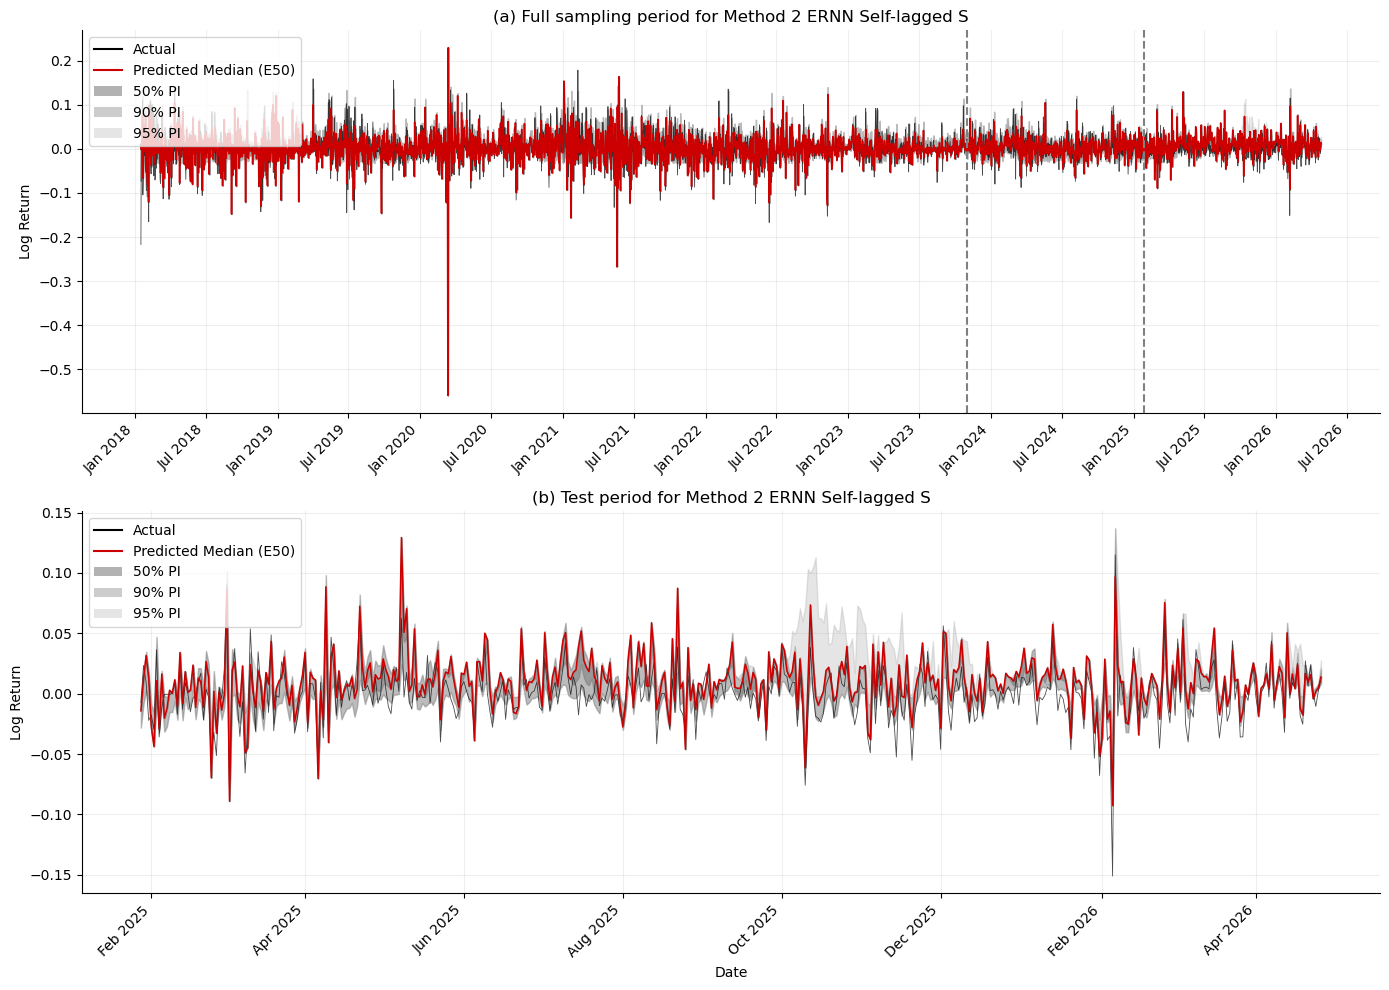

Plot saved to method2_sequential_ernn_s_self_predictions.png

TEST METRICS -- METHOD 2 ERNN S SELF-LAGGED
  tau       NLL      ASE
0.025 -2.235957 0.000050
0.050 -2.413426 0.000054
0.250 -2.527771 0.000145
0.500 -2.608456 0.000143
0.750 -2.752470 0.000082
0.950 -2.672271 0.000028
0.975 -2.482998 0.000030

Average NLL: -2.527621
Average ASE: 0.00007598

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

CONSTRAINT-BINDING RATE -- TEST PERIOD
tau=0.750 | reference=0.500 | 454/454 (100.00%)
tau=0.950 | reference=0.750 | 140/454 (30.84%)
tau=0.975 | reference=0.950 | 352/454 (77.53%)
tau=0.250 | reference=0.500 | 333/454 (73.35%)
tau=0.050 | reference=0.250 | 38/454 (8.37%)
tau=0.025 | reference=0.050 | 454/454 (100.00%)

Saved Method 2 outputs:
  method2_sequent

In [43]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 2 ERNN S SELF-LAGGED
# Run the tuning cell/file first. If the in-memory model dictionary
# is unavailable, this code reloads the saved checkpoint.
# ============================================================

m2_ernn_self_s_plot_levels = [
    0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975
]

m2_ernn_self_s_plot_order = [
    0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025
]

m2_ernn_self_s_plot_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}

m2_ernn_self_s_plot_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower',
}


# ============================================================
# Restore models if the tuning dictionary is not in memory
# ============================================================

if 'm2_ernn_self_s_final_models' not in globals():
    checkpoint = torch.load(
        'method2_sequential_ernn_s_self_best.pt',
        map_location='cpu',
        weights_only=False,
    )

    m2_ernn_self_s_final_models = {}

    for tau in checkpoint['estimation_order']:
        model = M2SequentialERNNSelfS(
            input_dim=X_train.shape[1],
            config=checkpoint['configs'][tau],
            direction=checkpoint['directions'][tau],
        )
        model.load_state_dict(checkpoint['model_state_dicts'][tau])
        model.eval()
        m2_ernn_self_s_final_models[tau] = model


# ============================================================
# Generate all seven full-sample forecasts sequentially
# ============================================================

def m2_ernn_self_s_generate_all_predictions(models, y, X):
    predictions = {}
    caviar_outputs = {}
    raw_fnn_outputs = {}
    constrained_fnn_outputs = {}
    sigma_values = {}

    for tau in m2_ernn_self_s_plot_order:
        reference_tau = m2_ernn_self_s_plot_reference[tau]
        reference = (
            None
            if reference_tau is None
            else predictions[reference_tau]
        )

        model = models[tau]
        model.eval()

        with torch.no_grad():
            (
                predictions[tau],
                caviar_outputs[tau],
                raw_fnn_outputs[tau],
                constrained_fnn_outputs[tau],
                sigma_values[tau],
            ) = model(y, X, reference)

    return (
        predictions,
        caviar_outputs,
        raw_fnn_outputs,
        constrained_fnn_outputs,
        sigma_values,
    )


m2_ernn_self_s_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32,
)

m2_ernn_self_s_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32,
)

(
    m2_ernn_self_s_all_preds_tensor,
    m2_ernn_self_s_all_caviar,
    m2_ernn_self_s_all_raw_fnn,
    m2_ernn_self_s_all_constrained_fnn,
    m2_ernn_self_s_sigma,
) = m2_ernn_self_s_generate_all_predictions(
    models=m2_ernn_self_s_final_models,
    y=m2_ernn_self_s_y_all,
    X=m2_ernn_self_s_X_all,
)

m2_ernn_self_s_all_preds = {
    tau: prediction.detach().cpu().numpy()
    for tau, prediction in m2_ernn_self_s_all_preds_tensor.items()
}


# ============================================================
# Plot full and test periods
# ============================================================

m2_ernn_self_s_all_dates = df.index
m2_ernn_self_s_test_dates = test_df.index
m2_ernn_self_s_test_start = len(train_df) + len(val_df)

m2_ernn_self_s_actual = df['log_return'].values
m2_ernn_self_s_actual_test = test_df['log_return'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'


def m2_ernn_self_s_draw_panel(ax, dates, actual, start=None):
    def values(tau):
        series = m2_ernn_self_s_all_preds[tau]
        return series if start is None else series[start:]

    ax.plot(dates, actual, color=actual_color, linewidth=0.6, alpha=0.7)
    ax.plot(
        dates,
        values(0.500),
        color=median_color,
        linewidth=1.1,
    )
    ax.fill_between(
        dates,
        values(0.025),
        values(0.975),
        color=interval_color,
        alpha=0.20,
    )
    ax.fill_between(
        dates,
        values(0.050),
        values(0.950),
        color=interval_color,
        alpha=0.40,
    )
    ax.fill_between(
        dates,
        values(0.250),
        values(0.750),
        color=interval_color,
        alpha=0.60,
    )
    ax.set_ylabel('Log Return')
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


m2_ernn_self_s_draw_panel(
    axes[0],
    m2_ernn_self_s_all_dates,
    m2_ernn_self_s_actual,
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    '(a) Full sampling period for Method 2 ERNN Self-lagged S'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m2_ernn_self_s_draw_panel(
    axes[1],
    m2_ernn_self_s_test_dates,
    m2_ernn_self_s_actual_test,
    start=m2_ernn_self_s_test_start,
)
axes[1].set_title('(b) Test period for Method 2 ERNN Self-lagged S')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

legend_elements = [
    Line2D([0], [0], color=actual_color, label='Actual'),
    Line2D([0], [0], color=median_color, label='Predicted Median (E50)'),
    Patch(facecolor=interval_color, alpha=0.60, label='50% PI'),
    Patch(facecolor=interval_color, alpha=0.40, label='90% PI'),
    Patch(facecolor=interval_color, alpha=0.20, label='95% PI'),
]

for axis in axes:
    axis.legend(handles=legend_elements, loc='upper left')
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()

m2_ernn_self_s_plot_name = (
    'method2_sequential_ernn_s_self_predictions.png'
)
plt.savefig(m2_ernn_self_s_plot_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f'Plot saved to {m2_ernn_self_s_plot_name}')


# ============================================================
# Test metrics
# ============================================================

m2_ernn_self_s_y_test = m2_ernn_self_s_y_all[
    m2_ernn_self_s_test_start:
]
m2_ernn_self_s_metric_rows = []

for tau in m2_ernn_self_s_plot_levels:
    q_test = m2_ernn_self_s_all_preds_tensor[tau][
        m2_ernn_self_s_test_start:
    ]
    sigma = m2_ernn_self_s_sigma[tau]
    nll = m2_ernn_self_s_loss(
        m2_ernn_self_s_y_test, q_test, sigma, tau
    ).item()
    ase = m2_ernn_self_s_ase(
        m2_ernn_self_s_y_test,
        q_test,
        tau,
    )

    m2_ernn_self_s_metric_rows.append(
        {
            'tau': tau,
            'NLL': nll,
            'ASE': ase,
        }
    )

m2_ernn_self_s_metrics_df = pd.DataFrame(m2_ernn_self_s_metric_rows)
m2_ernn_self_s_average_nll = m2_ernn_self_s_metrics_df['NLL'].mean()
m2_ernn_self_s_average_ase = m2_ernn_self_s_metrics_df['ASE'].mean()

print('\n' + '=' * 68)
print('TEST METRICS -- METHOD 2 ERNN S SELF-LAGGED')
print('=' * 68)
print(m2_ernn_self_s_metrics_df.to_string(index=False))
print(f'\nAverage NLL: {m2_ernn_self_s_average_nll:.6f}')
print(f'Average ASE: {m2_ernn_self_s_average_ase:.8f}')


# ============================================================
# Crossover analysis
# ============================================================

m2_ernn_self_s_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975),
]
m2_ernn_self_s_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

m2_ernn_self_s_total = 0
m2_ernn_self_s_tail_total = 0
m2_ernn_self_s_crossover_rows = []

print('\n' + '=' * 68)
print('CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT')
print('=' * 68)

for lower, upper in m2_ernn_self_s_pairs:
    lower_test = m2_ernn_self_s_all_preds_tensor[lower][
        m2_ernn_self_s_test_start:
    ]
    upper_test = m2_ernn_self_s_all_preds_tensor[upper][
        m2_ernn_self_s_test_start:
    ]
    violations = int((lower_test > upper_test).sum().item())
    rate = violations / len(lower_test)

    m2_ernn_self_s_total += violations
    if (lower, upper) in m2_ernn_self_s_tail_pairs:
        m2_ernn_self_s_tail_total += violations

    m2_ernn_self_s_crossover_rows.append(
        {
            'Lower': lower,
            'Upper': upper,
            'Violations': violations,
            'Rate': rate,
        }
    )

    tail_label = (
        ' <-- TAIL'
        if (lower, upper) in m2_ernn_self_s_tail_pairs
        else ''
    )
    print(
        f'({lower:.3f}, {upper:.3f}): '
        f'{violations} ({100 * rate:.2f}%){tail_label}'
    )

m2_ernn_self_s_total_rate = m2_ernn_self_s_total / (
    len(m2_ernn_self_s_y_test) * len(m2_ernn_self_s_pairs)
)
m2_ernn_self_s_tail_rate = m2_ernn_self_s_tail_total / (
    len(m2_ernn_self_s_y_test) * len(m2_ernn_self_s_tail_pairs)
)

print(
    f'\nTotal violations: {m2_ernn_self_s_total} '
    f'({100 * m2_ernn_self_s_total_rate:.2f}%)'
)
print(
    f'Tail violations: {m2_ernn_self_s_tail_total} '
    f'({100 * m2_ernn_self_s_tail_rate:.2f}%)'
)


# ============================================================
# Constraint-binding diagnostic
# ============================================================

m2_ernn_self_s_binding_rows = []

print('\n' + '=' * 68)
print('CONSTRAINT-BINDING RATE -- TEST PERIOD')
print('=' * 68)

for tau in m2_ernn_self_s_plot_order:
    direction = m2_ernn_self_s_plot_direction[tau]
    reference_tau = m2_ernn_self_s_plot_reference[tau]

    if direction is None:
        continue

    model = m2_ernn_self_s_final_models[tau]
    psi = (
        (1.0 - M2_ERNN_SELF_S_PSI_MARGIN)
        * torch.sigmoid(model.psi_raw)
    )
    caviar = m2_ernn_self_s_all_caviar[tau][
        m2_ernn_self_s_test_start:
    ]
    raw_fnn = m2_ernn_self_s_all_raw_fnn[tau][
        m2_ernn_self_s_test_start:
    ]
    reference = m2_ernn_self_s_all_preds_tensor[reference_tau][
        m2_ernn_self_s_test_start:
    ]
    raw_hybrid = psi * caviar + (1.0 - psi) * raw_fnn

    if direction == 'upper':
        binding = raw_hybrid < (
            reference + M2_ERNN_SELF_S_DELTA
        )
    else:
        binding = raw_hybrid > (
            reference - M2_ERNN_SELF_S_DELTA
        )

    binding_count = int(binding.sum().item())
    binding_rate = binding.float().mean().item()

    m2_ernn_self_s_binding_rows.append(
        {
            'Tau': tau,
            'Reference': reference_tau,
            'Direction': direction,
            'Binding_Count': binding_count,
            'Binding_Rate': binding_rate,
        }
    )
    print(
        f'tau={tau:.3f} | reference={reference_tau:.3f} | '
        f'{binding_count}/{len(binding)} ({100 * binding_rate:.2f}%)'
    )


# ============================================================
# Save outputs
# ============================================================

m2_ernn_self_s_metrics_df.to_csv(
    'method2_sequential_ernn_s_self_test_metrics.csv',
    index=False,
)
pd.DataFrame(m2_ernn_self_s_crossover_rows).to_csv(
    'method2_sequential_ernn_s_self_crossover.csv',
    index=False,
)
pd.DataFrame(m2_ernn_self_s_binding_rows).to_csv(
    'method2_sequential_ernn_s_self_binding_rates.csv',
    index=False,
)

print('\nSaved Method 2 outputs:')
print('  method2_sequential_ernn_s_self_predictions.png')
print('  method2_sequential_ernn_s_self_test_metrics.csv')
print('  method2_sequential_ernn_s_self_crossover.csv')
print('  method2_sequential_ernn_s_self_binding_rates.csv')

# Cross over dealing 3

In [50]:
"""Method 3, Specification 1: Hybrid ERNN S self-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_ernn_s_self_results")

# This standalone chunk estimates only the model supplied by the user:
# Hybrid ERNN, symmetric form, self-lagged recursion.
MODELS_TO_RUN = [("ernn", "s", "self")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_ernn_s_self_validation_summary.csv", index=False
        )
    print("\nMethod 3 ERNN S self-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-17 11:29:01,760] A new study created in memory with name: no-name-2e2ae34f-8d60-46d3-a26c-0b4ea07da197



METHOD 3 SPACING: ERNN S SELF
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-17 11:29:24,637] Trial 0 finished with value: 0.8025425672531128 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8025425672531128.
[I 2026-08-17 11:29:45,966] Trial 1 finished with value: -0.2274821251630783 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.2274821251630783.
[I 2026-08-17 11:29:49,143] Trial 2 finished with value: 0.8977494239807129 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': True,

[I 2026-08-17 12:36:40,319] A new study created in memory with name: no-name-efe8de2c-51f3-45cf-b4ee-775b76a8db51


...

[I 2026-08-17 12:45:51,385] Trial 0 finished with value: 0.5041185617446899 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.5041185617446899.
[I 2026-08-17 12:45:52,825] Trial 1 finished with value: -0.7729104161262512 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7729104161262512.
[I 2026-08-17 12:45:53,752] Trial 2 finished with value: 1.4520848989486694 and parameters: {'n_hidden_layers': 2, 'activ

[I 2026-08-17 12:47:42,980] A new study created in memory with name: no-name-37a144b5-2f64-4b03-a992-9c3b63549d42


Selected trial #163 | val NLL=-2.548712 | calibration=0.000046 | mean delta=0.008995
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-17 12:47:44,826] Trial 0 finished with value: 0.6448979377746582 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6448979377746582.
[I 2026-08-17 12:47:46,588] Trial 1 finished with value: 1.5522066354751587 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6448979377746582.
[I 2026-08-17 12:47:47,074] Trial 2 finished with value: 1.6965969800949097 and parameters: {'n_hidden_

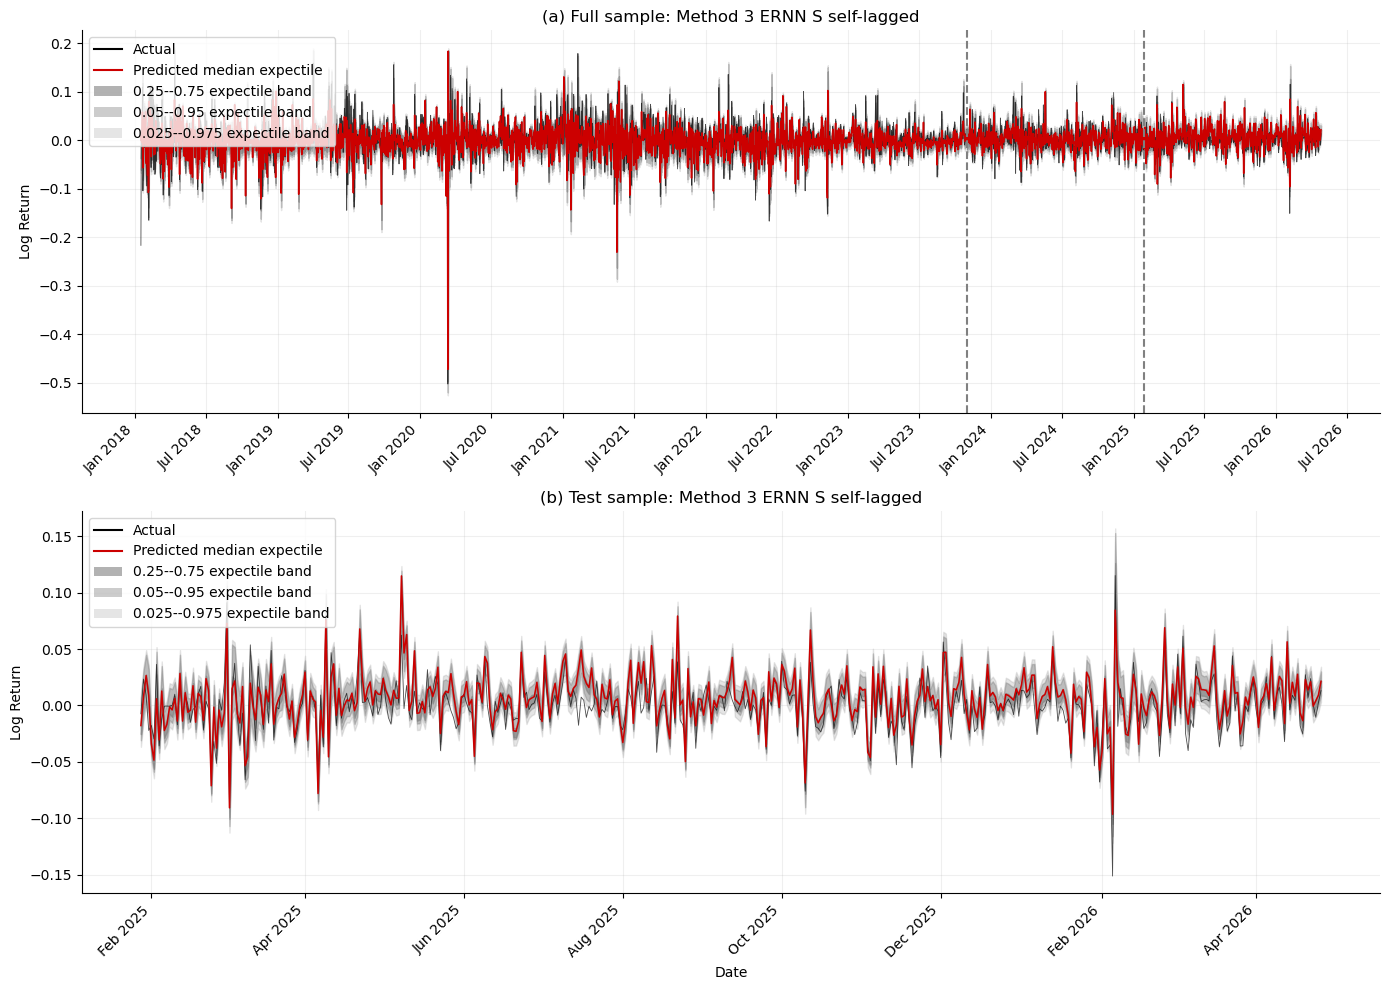


METHOD 3 ERNN S SELF-LAGGED -- TEST RESULTS
               model  test_T  average_nll  average_ase  crossover  tail
Method 3 ERNN S Self     454    -2.707517     0.000055          0     0

Per-level results:
  tau       nll      ase    sigma
0.025 -2.578588 0.000024 0.007934
0.050 -2.547305 0.000046 0.010925
0.250 -2.734167 0.000093 0.016546
0.500 -2.692123 0.000106 0.021513
0.750 -2.848126 0.000069 0.015623
0.950 -2.801630 0.000028 0.008515
0.975 -2.750681 0.000018 0.006096

Learned-spacing diagnostics:
  tau  reference_tau direction  mean_delta  min_delta  max_delta     sd_delta  near_zero_count  near_zero_rate
0.025           0.05     lower    0.005755   0.005674   0.005868 3.439937e-05                0             0.0
0.050           0.25     lower    0.005886   0.001143   0.043545 4.855538e-03                0             0.0
0.250           0.50     lower    0.005564   0.004140   0.009604 6.409102e-04                0             0.0
0.750           0.50     upper    0.001961   

In [52]:
"""Plot and evaluate Method 3 ERNN S self-lagged on the test sample.

Run after the tuning/data-preparation code. Expected notebook objects:
df, train_df, val_df, test_df, feature_cols, X_train and Method3SpacingModel.
"""

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

RESULT_DIR = Path("method3_spacing_ernn_s_self_results")
MODEL_DIR = RESULT_DIR / "ernn_s_self"
CHECKPOINT_PATH = MODEL_DIR / "method3_spacing_ernn_s_self_best.pt"
PLOT_PATH = MODEL_DIR / "method3_spacing_ernn_s_self.png"
METRICS_PATH = MODEL_DIR / "method3_spacing_ernn_s_self_test_metrics.csv"
SUMMARY_PATH = MODEL_DIR / "method3_spacing_ernn_s_self_test_summary.csv"
DELTA_PATH = MODEL_DIR / "method3_spacing_ernn_s_self_delta_summary.csv"
PREDICTIONS_PATH = MODEL_DIR / "method3_spacing_ernn_s_self_test_predictions.csv"


required_objects = (
    "df", "train_df", "val_df", "test_df", "feature_cols", "X_train"
)
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError("Run the data-preparation cells first. Missing: " + ", ".join(missing))

if "Method3SpacingModel" not in globals():
    from method3_spacing_ernn_s_self_tuning import Method3SpacingModel

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}. Run the tuning code first."
    )


# ---------------------------------------------------------------------------
# Reload all seven selected level models
# ---------------------------------------------------------------------------

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
if checkpoint.get("distribution") != "ernn":
    raise ValueError("The checkpoint is not an ERNN checkpoint.")
if checkpoint.get("form") != "s" or checkpoint.get("lag") != "self":
    raise ValueError("The checkpoint is not the ERNN S self-lagged model.")

models = {}
for level in ORDER:
    model = Method3SpacingModel(
        input_dim=X_train.shape[1],
        config=checkpoint["configs"][level],
        distribution="ernn",
        form="s",
        lag="self",
        direction=checkpoint["direction"][level],
    )
    model.load_state_dict(checkpoint["model_state_dicts"][level])
    model.eval()
    models[level] = model


# ---------------------------------------------------------------------------
# Generate full-sample forecasts sequentially from the median outwards
# ---------------------------------------------------------------------------

X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y_all = torch.tensor(df["log_return"].values, dtype=torch.float32)
predictions, deltas, sigmas = {}, {}, {}

for level in ORDER:
    reference_level = REFERENCE[level]
    reference = None if reference_level is None else predictions[reference_level]
    with torch.no_grad():
        prediction, _, _, delta, sigma = models[level](y_all, X_all, reference)
    predictions[level] = prediction.detach()
    deltas[level] = None if delta is None else delta.detach()
    sigmas[level] = sigma.detach()

test_start = len(train_df) + len(val_df)
y_test = y_all[test_start:]
test_dates = test_df.index

if len(y_test) != len(test_dates):
    raise ValueError("The calculated test slice does not match test_df.")


# ---------------------------------------------------------------------------
# Plot full sample and test sample
# ---------------------------------------------------------------------------

prediction_np = {level: predictions[level].cpu().numpy() for level in LEVELS}
actual_np = df["log_return"].to_numpy()


def draw_panel(axis, dates, actual, start=None):
    def values(level):
        series = prediction_np[level]
        return series if start is None else series[start:]

    axis.plot(dates, actual, color="#000000", linewidth=0.6, alpha=0.70)
    axis.plot(dates, values(0.500), color="#CC0000", linewidth=1.1)
    axis.fill_between(dates, values(0.025), values(0.975), color="#808080", alpha=0.20)
    axis.fill_between(dates, values(0.050), values(0.950), color="#808080", alpha=0.40)
    axis.fill_between(dates, values(0.250), values(0.750), color="#808080", alpha=0.60)
    axis.set_ylabel("Log Return")
    axis.grid(True, alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


figure, axes = plt.subplots(2, 1, figsize=(14, 10))
draw_panel(axes[0], df.index, actual_np)
axes[0].axvline(train_df.index[-1], color="gray", linestyle="--")
axes[0].axvline(val_df.index[-1], color="gray", linestyle="--")
axes[0].set_title("(a) Full sample: Method 3 ERNN S self-lagged")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

draw_panel(axes[1], test_dates, test_df["log_return"].to_numpy(), start=test_start)
axes[1].set_title("(b) Test sample: Method 3 ERNN S self-lagged")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

legend = [
    Line2D([0], [0], color="#000000", label="Actual"),
    Line2D([0], [0], color="#CC0000", label="Predicted median expectile"),
    Patch(facecolor="#808080", alpha=0.60, label="0.25--0.75 expectile band"),
    Patch(facecolor="#808080", alpha=0.40, label="0.05--0.95 expectile band"),
    Patch(facecolor="#808080", alpha=0.20, label="0.025--0.975 expectile band"),
]
for axis in axes:
    axis.legend(handles=legend, loc="upper left")
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ---------------------------------------------------------------------------
# Test AGD NLL and asymmetric squared error
# ---------------------------------------------------------------------------


def agd_nll(y, expectile, sigma, tau):
    residual = y - expectile
    tau_tensor = torch.tensor(tau, dtype=y.dtype, device=y.device)
    weight = torch.abs(tau_tensor - (residual < 0).to(y.dtype))
    constant = (
        torch.log(
            torch.sqrt(torch.pi / tau_tensor)
            + torch.sqrt(torch.pi / (1.0 - tau_tensor))
        )
        - np.log(2.0)
    )
    return (
        torch.log(sigma)
        + constant
        + weight * residual.square() / sigma.square()
    ).mean()


def asymmetric_squared_error(y, expectile, tau):
    residual = y - expectile
    weight = torch.where(
        residual >= 0,
        torch.full_like(residual, tau),
        torch.full_like(residual, 1.0 - tau),
    )
    return (weight * residual.square()).mean()


metric_rows = []
for level in LEVELS:
    prediction_test = predictions[level][test_start:]
    metric_rows.append({
        "tau": level,
        "nll": agd_nll(y_test, prediction_test, sigmas[level], level).item(),
        "ase": asymmetric_squared_error(y_test, prediction_test, level).item(),
        "sigma": sigmas[level].item(),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(METRICS_PATH, index=False)


# ---------------------------------------------------------------------------
# Crossover and learned-spacing diagnostics
# ---------------------------------------------------------------------------

test_matrix = torch.stack(
    [predictions[level][test_start:] for level in LEVELS], dim=1
)
violations = test_matrix[:, :-1] > test_matrix[:, 1:]
pair_counts = violations.sum(dim=0)
total_crossover = int(violations.sum().item())
tail_crossover = int((pair_counts[0] + pair_counts[-1]).item())

delta_rows = []
for level in LEVELS:
    if deltas[level] is None:
        continue
    delta_test = deltas[level][test_start:]
    delta_rows.append({
        "tau": level,
        "reference_tau": REFERENCE[level],
        "direction": DIRECTION[level],
        "mean_delta": delta_test.mean().item(),
        "min_delta": delta_test.min().item(),
        "max_delta": delta_test.max().item(),
        "sd_delta": delta_test.std(unbiased=False).item(),
        "near_zero_count": int((delta_test < 1e-6).sum().item()),
        "near_zero_rate": (delta_test < 1e-6).float().mean().item(),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(DELTA_PATH, index=False)

summary_df = pd.DataFrame([{
    "model": "Method 3 ERNN S Self",
    "test_T": len(y_test),
    "average_nll": metrics_df["nll"].mean(),
    "average_ase": metrics_df["ase"].mean(),
    "crossover": total_crossover,
    "tail": tail_crossover,
}])
summary_df.to_csv(SUMMARY_PATH, index=False)


# ---------------------------------------------------------------------------
# Detailed test predictions and adjacent gaps
# ---------------------------------------------------------------------------

prediction_table = pd.DataFrame({
    "date": test_dates,
    "actual": y_test.cpu().numpy(),
})
for level in LEVELS:
    prediction_table[f"e_{level:.3f}"] = predictions[level][test_start:].cpu().numpy()
for left, right in zip(LEVELS[:-1], LEVELS[1:]):
    prediction_table[f"gap_{left:.3f}_{right:.3f}"] = (
        predictions[right][test_start:] - predictions[left][test_start:]
    ).cpu().numpy()
prediction_table["min_adjacent_gap"] = prediction_table[
    [column for column in prediction_table if column.startswith("gap_")]
].min(axis=1)
prediction_table.to_csv(PREDICTIONS_PATH, index=False)


print("\nMETHOD 3 ERNN S SELF-LAGGED -- TEST RESULTS")
print(summary_df.to_string(index=False))
print("\nPer-level results:")
print(metrics_df.to_string(index=False))
print("\nLearned-spacing diagnostics:")
print(delta_df.to_string(index=False))
print(f"\nPlot saved to: {PLOT_PATH}")
print(f"Detailed predictions saved to: {PREDICTIONS_PATH}")